In [ ]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

  ##  EDA  :
  -----------------------------

**1.1 Load data**

In [ ]:
df = pd.read_csv('Fifa.csv')

**1.2 Quick overview of the dataset**

In [ ]:
print("general info of the dataset:")
print(df.info())
print("="*50)
print(df.head())
print("="*50)
print(df.tail())
print("="*50)
duplicates = df.duplicated().sum()
print("="*50)
print("5. Basic Statistics (Numerical)")
print(df.describe())
print(f"Number of duplicates: {duplicates}")
print("="*50)
print("\nDataset shape (rows, columns):")
df.shape

general info of the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB
None
                 Name Country Position  Age  Overall_Rating  Future Potential  \
0  Agostinho Mabululu  Angola       LW   30              68                68   
1     Mahmoud Gennesh   Egypt       GK   35              67                67   
2      Sobhi Suleiman   E

(19667, 9)

**1.3 Are there any missing values? How many, and in which columns?**

Checking missing values

In [ ]:
print("\nMissing values per column:")
print(df.isnull().sum())
print("="*50)
for col in df.columns:
     print(f"Column {col}:")
     print(f"Number of unique values: {len(df[col].value_counts())}")
     print("------------------------------")


Missing values per column:
Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64
Column Name:
Number of unique values: 19551
------------------------------
Column Country:
Number of unique values: 164
------------------------------
Column Position:
Number of unique values: 17
------------------------------
Column Age:
Number of unique values: 30
------------------------------
Column Overall_Rating:
Number of unique values: 50
------------------------------
Column Future Potential:
Number of unique values: 49
------------------------------
Column Team:
Number of unique values: 1009
------------------------------
Column Value Per M$:
Number of unique values: 255
------------------------------
Column Total_Stats Score:
Number of unique values: 1438
------------------------------


--->> No null values found in the dataset


**1.4 Detect numeric vs text columns**


In [ ]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("The numerical features:", numerical_features)
print("The caterorical features:", categorical_features)

The numerical features: ['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']
The caterorical features: ['Name', 'Country', 'Position', 'Team']


In [ ]:
print("value count in every column for each row:")
for col in categorical_features:
     print(f"Column {col}:")
     print(df[col].value_counts())
     print("------------------------------")

value count in every column for each row:
Column Name:
Name
Diego González               3
Nicolás González             3
Diego Valdés                 3
Adama Fofana                 3
Lucas Rodríguez              3
                            ..
Martin Johansson Zanjachi    1
Erik Lindell                 1
Tesfaldet Tekie              1
Samuel Portugal Lima         1
Yuning Zhang                 1
Name: count, Length: 19551, dtype: int64
------------------------------
Column Country:
Country
England      1549
Spain        1146
Germany      1101
Argentina     981
France        873
             ... 
Nepal           1
Bhutan          1
Gibraltar       1
Lebanon         1
Malaysia        1
Name: count, Length: 164, dtype: int64
------------------------------
Column Position:
Position
CB     2981
ST     2697
CM     2507
GK     2124
CDM    1358
LM     1279
RM     1203
RB     1100
CAM    1099
LB     1073
RW      707
LW      659
LWB     300
RWB     297
CF      280
RF        2
SW        1
Name:

**1.5 Distribution of Value Per M$**

we analyze the distribution of the "Value Per M$" feature to determine whether it is approximately normal or skewed. We will also calculate the skewness to better understand the shape of the distribution.

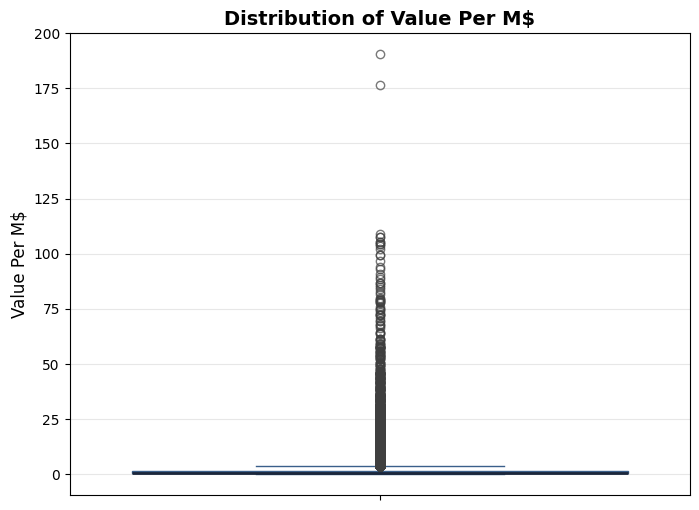

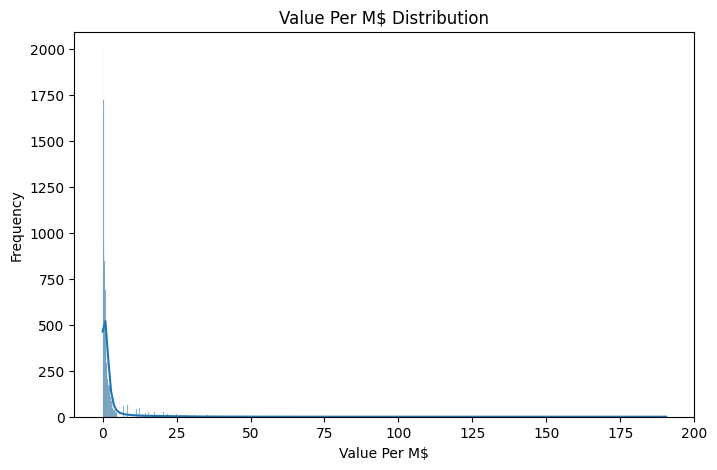

--------------------------------------------------
the skewness=7.983215201865151


In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(df['Value Per M$'],

            boxprops=dict(facecolor='#A7C7E7', color='#3A5F8A'),
            medianprops=dict(color='#1B263B', linewidth=2),
            whiskerprops=dict(color='#3A5F8A'),
            capprops=dict(color='#3A5F8A'),
            flierprops=dict(marker='o', color='#FF7F7F', alpha=0.7))
plt.title('Distribution of Value Per M$', fontsize=14, fontweight='bold')
plt.ylabel('Value Per M$', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()
#frequency distributions using histogram
plt.figure(figsize=(8,5))
sns.histplot(df["Value Per M$"], kde=True)
plt.title("Value Per M$ Distribution")
plt.xlabel("Value Per M$")
plt.ylabel("Frequency")
plt.show()
print("-"*50)
print (f"the skewness={df['Value Per M$'].skew()}")

The distribution of "Value Per M$" is right-skewed (positively skewed), as most players have low market values while a few players have very high values, creating a long tail to the right. The skewness value confirms this positive skew.

**1.6 Correlation with Value Per M$**

we analyze the correlation between numerical features to identify which ones are most related to "Value Per M$".

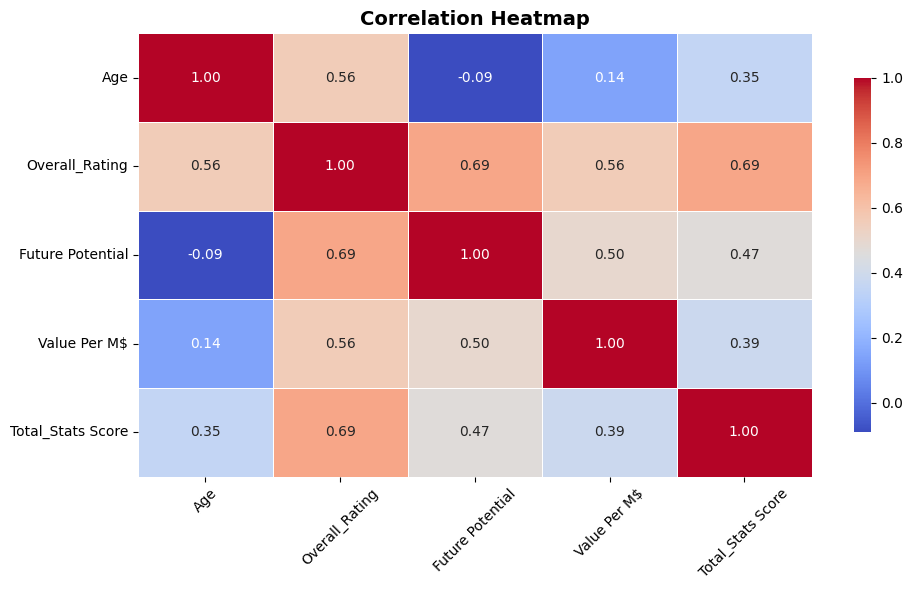

In [ ]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Overall_Rating has the highest correlation with Value Per M$ (correlation = 0.56), which means that player rating strongly affects market value.

*calculated the average Overall_Rating for each player position:*

In [ ]:
print(" 4. Average Overall_Rating per Position ")
print (df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False))

 4. Average Overall_Rating per Position 
Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
CAM    63.679709
CB     63.544448
LB     63.276794
ST     63.087505
RB     62.863636
CM     62.511767
GK     60.987288
Name: Overall_Rating, dtype: float64


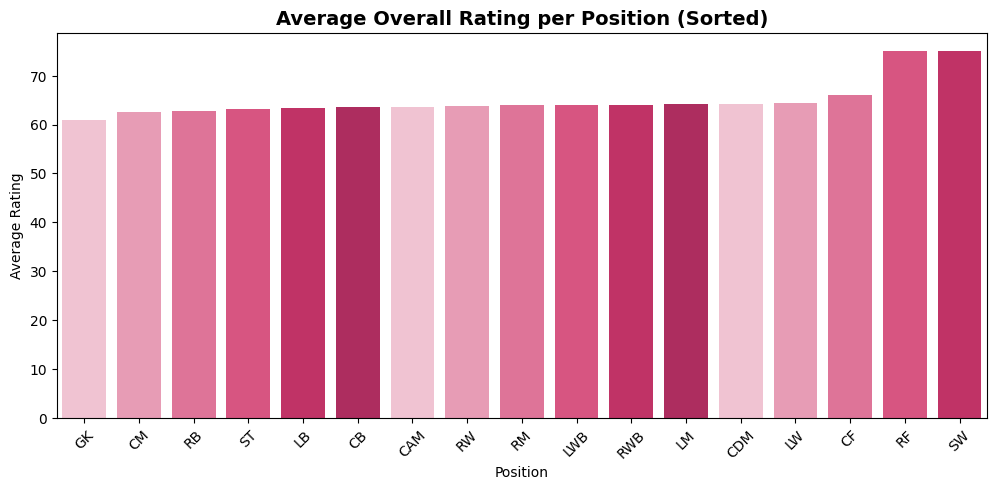

In [ ]:
plt.figure(figsize=(12,5))
pos_order = df.groupby('Position')['Overall_Rating'].mean().sort_values().reset_index()

sns.barplot(
    data=pos_order,
    x='Position',
    y='Overall_Rating',
    palette=['#F8BBD0', '#F48FB1', '#F06292', '#EC407A', '#D81B60', '#C2185B']
)

plt.title("Average Overall Rating per Position (Sorted)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel("Average Rating")
plt.xlabel("Position")
plt.show()

## Task 2 preprocessing :
---------------

***Removing some Column***:

In [ ]:
print("Dropping non-predictive and high-cardinality columns:")
print(f"  Name : not a predictive feature")
print(f"  Team : {df['Team'].nunique()} unique values, too high cardinality for encoding")
print("Keeping them would add 1000+ columns after OHE which causes overfitting and noise")

df_clean = df.drop(columns=['Name', 'Team'])
print("Shape after dropping:", df_clean.shape)

Dropping non-predictive and high-cardinality columns:
  Name : not a predictive feature
  Team : 1009 unique values, too high cardinality for encoding
Keeping them would add 1000+ columns after OHE which causes overfitting and noise
Shape after dropping: (19667, 7)


** Split the dataset into Train and Test sets (80/20)**

In [ ]:
train, test = train_test_split(df_clean, test_size=0.2, random_state=42)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (15733, 7)
Test shape: (3934, 7)


***outlier detction***:
***(boxplot to detect outliers)***

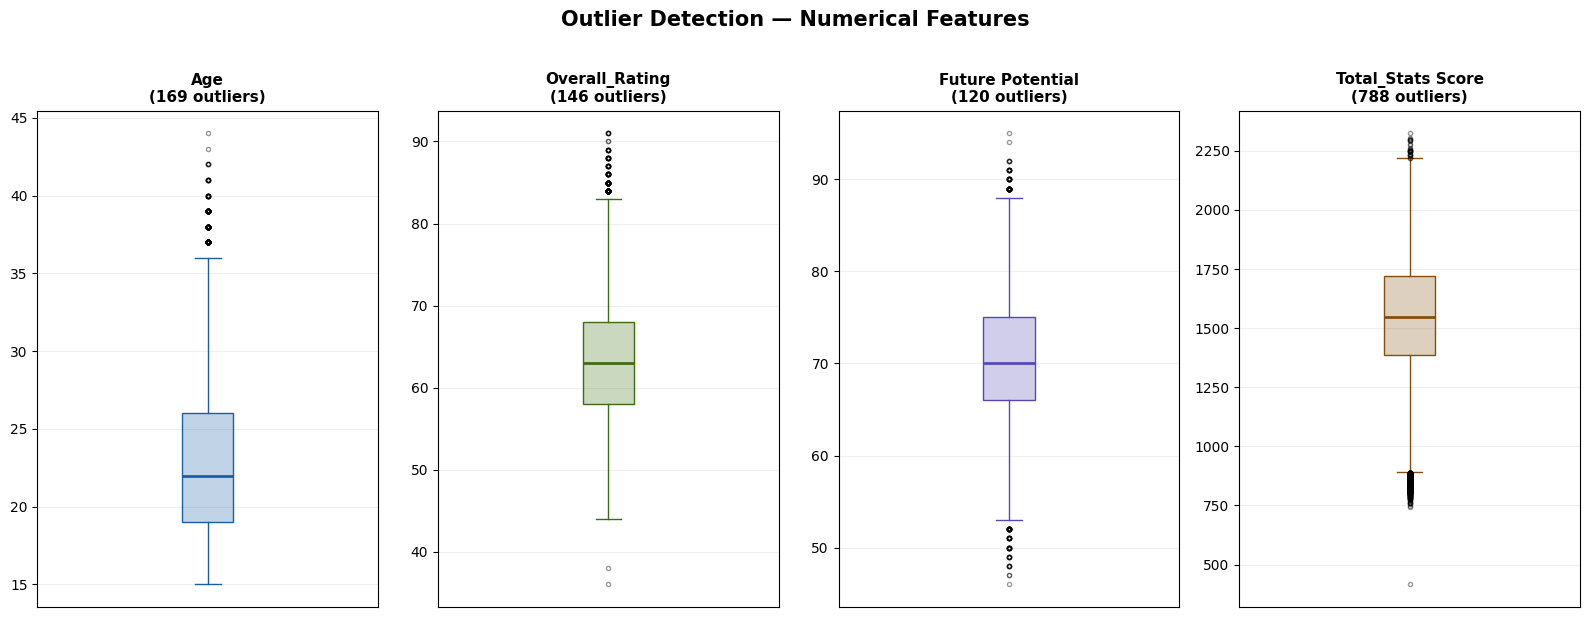

In [ ]:
num_cols_plot = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
colors = ['#185FA5', '#3B6D11', '#534AB7', '#854F0B']

fig, axes = plt.subplots(1, 4, figsize=(16, 6))
fig.suptitle('Outlier Detection — Numerical Features', fontsize=15, fontweight='bold', y=1.02)

for i, (col, color) in enumerate(zip(num_cols_plot, colors)):
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)).sum()

    axes[i].boxplot(df_clean[col].dropna(),
                    patch_artist=True,
                    boxprops=dict(facecolor=color+'44', color=color),
                    medianprops=dict(color=color, linewidth=2),
                    whiskerprops=dict(color=color),
                    capprops=dict(color=color),
                    flierprops=dict(marker='o', color=color, alpha=0.4, markersize=3))
    axes[i].set_title(f'{col}\n({n_out} outliers)', fontsize=11, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.2)
    axes[i].set_xticks([])

plt.tight_layout()
plt.show()

***Outlier handeling using IQR capping (except the target value [Value Per M$] )***:
 Outlier Capping using IQR (on train and test)

Capping outliers using IQR:

Age: capped to [8.50, 36.50]
Future Potential: capped to [52.50, 88.50]
Total_Stats Score: capped to [892.50, 2216.50]

Train shape: (15733, 7)
Test shape:  (3934, 7)


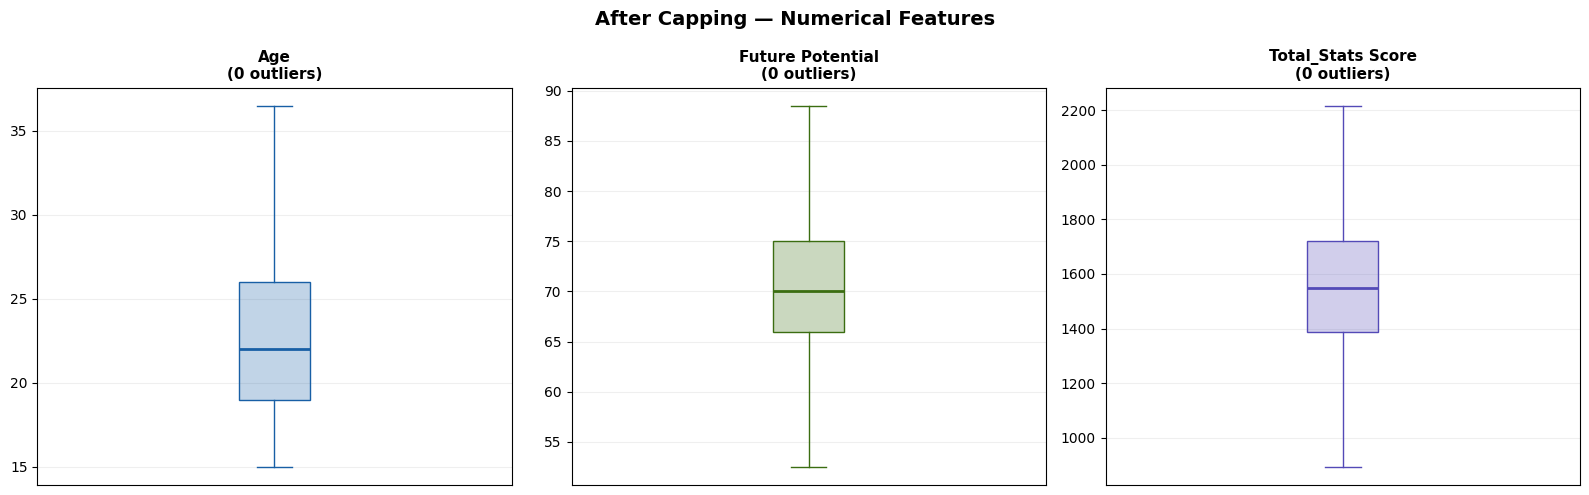

In [ ]:
#  Outlier Capping using IQR
cap_cols = ['Age', 'Future Potential', 'Total_Stats Score']

print("Capping outliers using IQR:\n")

for col in cap_cols:
    Q1    = train[col].quantile(0.25)
    Q3    = train[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    train[col] = np.where(train[col] < lower, lower, train[col])
    train[col] = np.where(train[col] > upper, upper, train[col])
    test[col]  = np.where(test[col]  < lower, lower, test[col])
    test[col]  = np.where(test[col]  > upper, upper, test[col])

    print(f"{col}: capped to [{lower:.2f}, {upper:.2f}]")

print("\nTrain shape:", train.shape)
print("Test shape: ", test.shape)

#  Boxplot after capping
colors = ['#185FA5', '#3B6D11', '#534AB7', '#854F0B']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('After Capping — Numerical Features', fontsize=14, fontweight='bold')

for i, (col, color) in enumerate(zip(cap_cols, colors)):
    axes[i].boxplot(train[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=color+'44', color=color),
                    medianprops=dict(color=color, linewidth=2),
                    whiskerprops=dict(color=color),
                    capprops=dict(color=color),
                    flierprops=dict(marker='o', color=color, alpha=0.4, markersize=3))
    axes[i].set_title(f'{col}\n(0 outliers)', fontsize=11, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.2)
    axes[i].set_xticks([])

plt.tight_layout()
plt.show()

Defining the Target Variable:

In [ ]:
X_train = train.drop(columns=['Value Per M$'])
y_train = train['Value Per M$']

X_test = test.drop(columns=['Value Per M$'])
y_test = test['Value Per M$']

In [ ]:
# Make sure no extra spaces in categorical columns
cat_cols = ['Position', 'Country']
for col in cat_cols:
    X_train[col] = X_train[col].str.strip()
    X_test[col]  = X_test[col].str.strip()

In [ ]:
#copy data for assignment 3
X_train_raw = X_train.copy()
X_test_raw  = X_test.copy()

**Encoding — One Hot Encoding on Position and country**

In [ ]:
#One-Hot Encoding was applied to Position and Country columns because they are nominal categorical variables with no inherent order between their categories.
X_train = pd.get_dummies(X_train, columns=['Position', 'Country'], drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=['Position', 'Country'], drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (15733, 181)
X_test shape:  (3934, 181)


In [ ]:
print("\nColumns:", X_train.columns.tolist())


Columns: ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score', 'Position_CB', 'Position_CDM', 'Position_CF', 'Position_CM', 'Position_GK', 'Position_LB', 'Position_LM', 'Position_LW', 'Position_LWB', 'Position_RB', 'Position_RF', 'Position_RM', 'Position_RW', 'Position_RWB', 'Position_ST', 'Position_SW', 'Country_Albania', 'Country_Algeria', 'Country_Angola', 'Country_Argentina', 'Country_Armenia', 'Country_Australia', 'Country_Austria', 'Country_Azerbaijan', 'Country_Barbados', 'Country_Belarus', 'Country_Belgium', 'Country_Benin', 'Country_Bermuda', 'Country_Bolivia', 'Country_Bosnia and Herzegovina', 'Country_Brazil', 'Country_Bulgaria', 'Country_Burkina Faso', 'Country_Burundi', 'Country_Cameroon', 'Country_Canada', 'Country_Cape Verde Islands', 'Country_Central African Republic', 'Country_Chad', 'Country_Chile', 'Country_China PR', 'Country_Chinese Taipei', 'Country_Colombia', 'Country_Comoros', 'Country_Congo', 'Country_Congo DR', 'Country_Costa Rica', 'Country_Croa

***Scalling***
***

In [ ]:
#Data Copy
#A copy of the dataset is created to keep the original data unchanged before applying scaling.
X_train_unscaled = X_train.copy()
X_test_unscaled  = X_test.copy()

In [ ]:
#  Scaling Numerical Features only
num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])
print("X_train shape:", X_train.shape)
print("X_test shape:  ", X_test.shape)
print("\nSample after scaling:")
print(X_train[num_cols].head(3).round(2))

X_train shape: (15733, 181)
X_test shape:   (3934, 181)

Sample after scaling:
        Age  Overall_Rating  Future Potential  Total_Stats Score
10156  0.44            0.48             -0.10               0.55
10392 -0.86           -1.06             -0.41              -0.66
8124   1.94            1.51              0.67               1.84


In [ ]:
print('Scaling done!')
display(X_train[num_cols].describe().round(3))

Scaling done!


,Age,Overall_Rating,Future Potential,Total_Stats Score
count,15733.000,15733.000,15733.000,15733.000
mean,-0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000
min,-1.720,-3.245,-2.814,-2.304
25%,-0.858,-0.673,-0.723,-0.525
50%,-0.211,-0.031,-0.103,0.045
75%,0.651,0.612,0.672,0.662
max,2.915,3.569,2.763,2.441


## Threshold

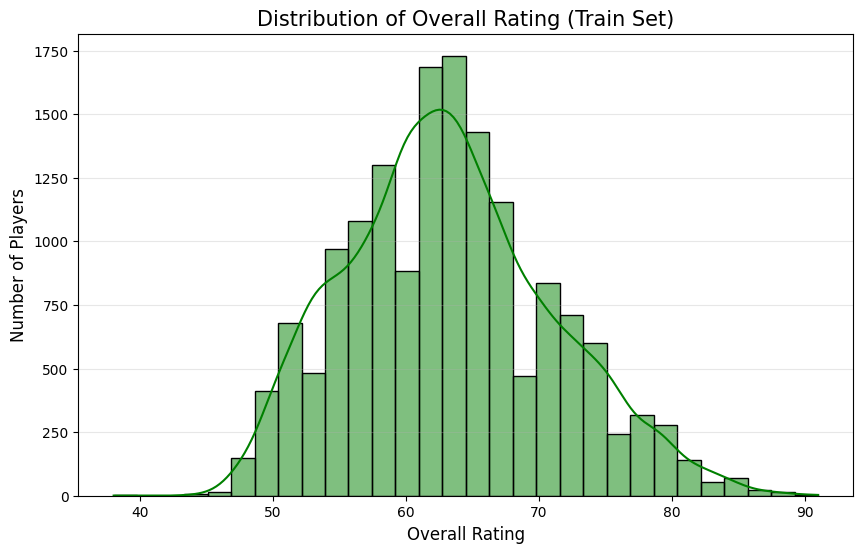

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(X_train_unscaled['Overall_Rating'], kde=True, color='green', bins=30)
plt.title('Distribution of Overall Rating (Train Set)', fontsize=15)
plt.xlabel('Overall Rating', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

splitting by histogram will be imbalanced.

Thresholds used for each category:
Low: 38.00 to 58.00
Mid: 58.00 to 63.00
High: 63.00 to 68.00
Elite: 68.00 to 91.00
Class distribution in Train Set:
Performance_Tier
Low      4403
Mid      4117
Elite    3753
High     3460
Name: count, dtype: int64


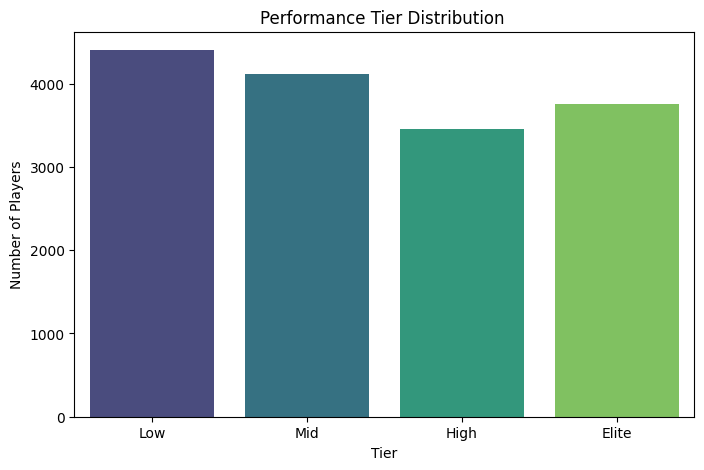

In [ ]:

# 4 labels
performance_labels = ['Low', 'Mid', 'High', 'Elite']

train['Performance_Tier'], bins = pd.qcut(X_train_unscaled['Overall_Rating'], q=4,labels=performance_labels,retbins=True)

test['Performance_Tier'] = pd.cut(X_test_unscaled['Overall_Rating'], bins=bins, labels=performance_labels,include_lowest=True)

test['Performance_Tier'] = test['Performance_Tier'].fillna('Low')
# Thresholds
print("Thresholds used for each category:")
for i in range(len(performance_labels)):
    print(f"{performance_labels[i]}: {bins[i]:.2f} to {bins[i+1]:.2f}")

# Num of player in each category
print("Class distribution in Train Set:")
print(train['Performance_Tier'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=train, x='Performance_Tier', palette='viridis', order=performance_labels)
plt.title('Performance Tier Distribution ')
plt.xlabel('Tier')
plt.ylabel('Number of Players')
plt.show()

Class distribution in Test Set:
Performance_Tier
Low      1165
Mid       985
Elite     947
High      837
Name: count, dtype: int64


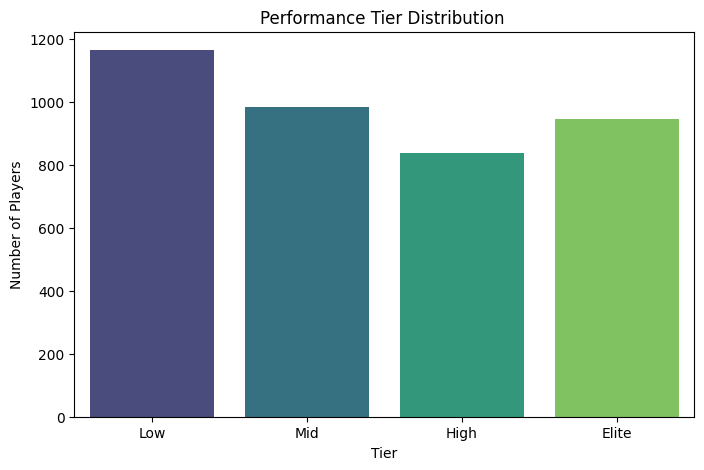

In [ ]:
# Num of player in each category in test set
print("Class distribution in Test Set:")
print(test['Performance_Tier'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=test, x='Performance_Tier', palette='viridis', order=performance_labels)
plt.title('Performance Tier Distribution ')
plt.xlabel('Tier')
plt.ylabel('Number of Players')
plt.show()

## Polynomial Regression

<Axes: title={'center': 'Relationship between Overall Rating and Value (in M$)'}, xlabel='Overall_Rating', ylabel='Value Per M$'>

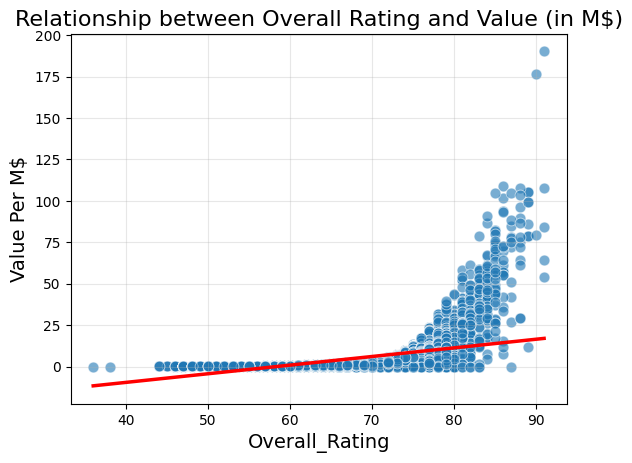

In [ ]:
#scatter plot
sns.scatterplot(
    data=df,
    x='Overall_Rating',
    y='Value Per M$',
    alpha=0.6,
    s=60
)

plt.title('Relationship between Overall Rating and Value (in M$)', fontsize=16)
plt.xlabel('Overall Rating', fontsize=14)
plt.ylabel('Value Per M$', fontsize=14)
plt.grid(True, alpha=0.3)

#Regression line
sns.regplot(
    data=df,
    x='Overall_Rating',
    y='Value Per M$',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2.5},
    ci=95
)

before any modeling i wanted to see the relation between target(value per M$) and the most correlated feature to it (overall_rating)  , it dose  not seem as linear relation so it is better here to preform polynomial regression

In [ ]:
#baseline Linear Regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_pred_test  = lr.predict(X_test)

# model metrics
def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"{label} → MAE:{mae:.3f} | MSE:{mse:.3f} | RMSE:{rmse:.3f} | R²:{r2:.3f}")

evaluate(y_train, y_pred_train, "Train")
evaluate(y_test,  y_pred_test,  "Test")

Train → MAE:2.865 | MSE:30.136 | RMSE:5.490 | R²:0.401
Test → MAE:2.955 | MSE:38.596 | RMSE:6.213 | R²:0.378


underfitting > bad results , probably  not a regression relation

Polynomial Degrees 1 → 4

In [ ]:
#Polynomial regression
from sklearn.preprocessing import PolynomialFeatures

num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']

# numerical feauters
X_train_num = X_train[num_cols]
X_test_num  = X_test[num_cols]

#other feauters
other_cols = [c for c in X_train.columns if c not in num_cols]
X_train_other = X_train[other_cols].values
X_test_other  = X_test[other_cols].values

degrees = [1, 2, 3, 4]
results = []

for deg in degrees:
    poly = PolynomialFeatures(degree=deg, include_bias=False)

    X_tr_poly = np.hstack([poly.fit_transform(X_train_num), X_train_other])
    X_te_poly = np.hstack([poly.transform(X_test_num),      X_test_other])

    model = LinearRegression()
    model.fit(X_tr_poly, y_train)

    r2_train = r2_score(y_train, model.predict(X_tr_poly))
    r2_test  = r2_score(y_test,  model.predict(X_te_poly))

    results.append({'degree': deg, 'Train R²': r2_train, 'Test R²': r2_test})
    print(f"Degree {deg} : Train R²: {r2_train:.4f} | Test R²: {r2_test:.4f}")

results_df = pd.DataFrame(results)

Degree 1 : Train R²: 0.4010 | Test R²: 0.3778
Degree 2 : Train R²: 0.7585 | Test R²: 0.7368
Degree 3 : Train R²: 0.9360 | Test R²: 0.9232
Degree 4 : Train R²: 0.9747 | Test R²: 0.9697


Degree vs Performance

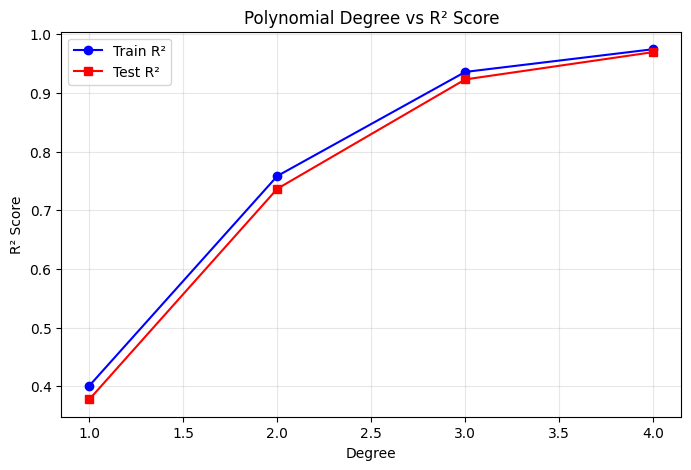

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(results_df['degree'], results_df['Train R²'], marker='o', label='Train R²', color='blue')
plt.plot(results_df['degree'], results_df['Test R²'],  marker='s', label='Test R²',  color='red')
plt.title('Polynomial Degree vs R² Score')
plt.xlabel('Degree')
plt.ylabel('R² Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

model performance increases when degree increases

Which degree gives the best generalization? Justify using the train/test gap?     

Degree 4 achieves the best generalization. Despite being the highest degree, it has the smallest train/test gap (0.005).
 At the same time, it achieves the highest Test R² (0.9697), confirming that the additional polynomial features genuinely capture real patterns in the data rather than memorizing noise.
 i will perform regularzation control overfitting.

LASSO AND RIDGE ON THe BEST DEGREE

In [ ]:
from sklearn.linear_model import Ridge, Lasso

#best degree = 4
best_deg = 4
poly = PolynomialFeatures(degree=best_deg, include_bias=False)
X_tr_poly = np.hstack([poly.fit_transform(X_train_num), X_train_other])
X_te_poly = np.hstack([poly.transform(X_test_num),      X_test_other])

alphas = np.logspace(-3, 3, 50)  #0.001 → 1000

ridge_train_rmse, ridge_test_rmse = [], []
lasso_train_rmse, lasso_test_rmse = [], []

for alpha in alphas:
    # Ridge
    r = Ridge(alpha=alpha)
    r.fit(X_tr_poly, y_train)
    ridge_train_rmse.append(np.sqrt(mean_squared_error(y_train, r.predict(X_tr_poly))))
    ridge_test_rmse.append( np.sqrt(mean_squared_error(y_test,  r.predict(X_te_poly))))

    # Lasso
    l = Lasso(alpha=alpha, max_iter=10000)
    l.fit(X_tr_poly, y_train)
    lasso_train_rmse.append(np.sqrt(mean_squared_error(y_train, l.predict(X_tr_poly))))
    lasso_test_rmse.append( np.sqrt(mean_squared_error(y_test,  l.predict(X_te_poly))))

Regularization Curves

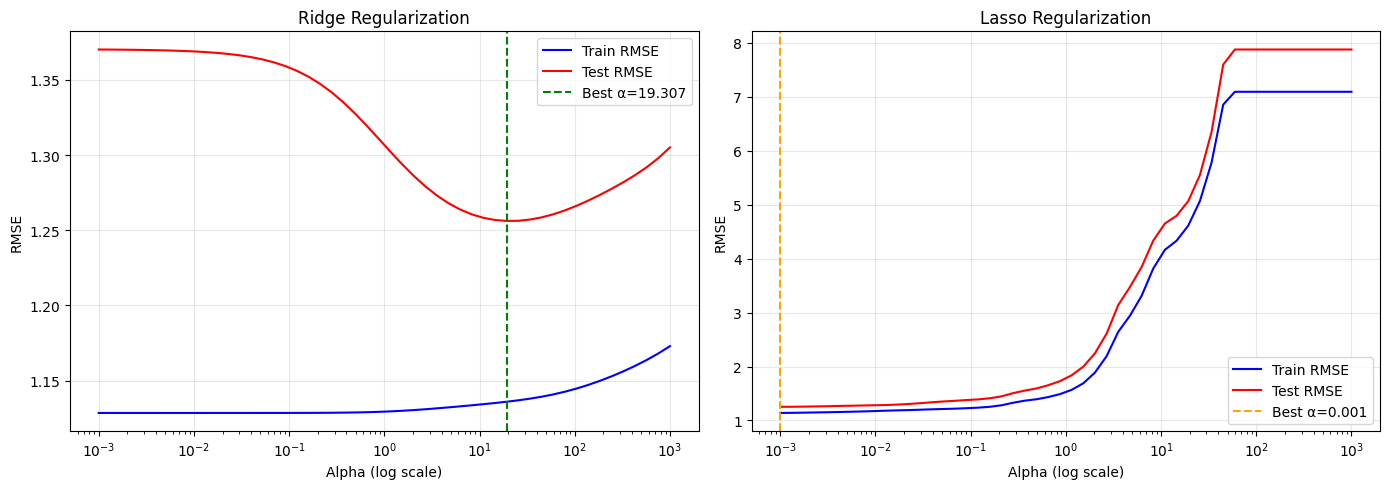

Best Ridge alpha: 19.3070
Best Lasso alpha: 0.0010


In [ ]:
best_ridge_alpha = alphas[np.argmin(ridge_test_rmse)]
best_lasso_alpha = alphas[np.argmin(lasso_test_rmse)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge
axes[0].semilogx(alphas, ridge_train_rmse, label='Train RMSE', color='blue')
axes[0].semilogx(alphas, ridge_test_rmse,  label='Test RMSE',  color='red')
axes[0].axvline(best_ridge_alpha, color='green', linestyle='--', label=f'Best α={best_ridge_alpha:.3f}')
axes[0].set_title('Ridge Regularization')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Lasso
axes[1].semilogx(alphas, lasso_train_rmse, label='Train RMSE', color='blue')
axes[1].semilogx(alphas, lasso_test_rmse,  label='Test RMSE',  color='red')
axes[1].axvline(best_lasso_alpha, color='orange', linestyle='--', label=f'Best α={best_lasso_alpha:.3f}')
axes[1].set_title('Lasso Regularization')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('RMSE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best Ridge alpha: {best_ridge_alpha:.4f}")
print(f"Best Lasso alpha: {best_lasso_alpha:.4f}")

In [ ]:
best_ridge = Ridge(alpha=best_ridge_alpha)
best_ridge.fit(X_tr_poly, y_train)
ASS2_REG_R2 = r2_score(y_test, best_ridge.predict(X_te_poly))
print(f"ASS2 Baseline Ridge R²       : {ASS2_REG_R2:.4f}")

ASS2 Baseline Ridge R²       : 0.9746


In [ ]:
#Ridge & Lasso RMSE Results
results_df = pd.DataFrame({
    'Alpha': alphas,
    'Ridge_Train_RMSE': ridge_train_rmse,
    'Ridge_Test_RMSE': ridge_test_rmse,
    'Lasso_Train_RMSE': lasso_train_rmse,
    'Lasso_Test_RMSE': lasso_test_rmse
})

print("Ridge & Lasso RMSE Results:")
print(results_df.head(10))


Ridge & Lasso RMSE Results:
      Alpha  Ridge_Train_RMSE  Ridge_Test_RMSE  Lasso_Train_RMSE  \
0  0.001000          1.128431         1.370169          1.139844   
1  0.001326          1.128431         1.370116          1.141892   
2  0.001758          1.128432         1.370047          1.145216   
3  0.002330          1.128432         1.369959          1.148923   
4  0.003089          1.128432         1.369846          1.152704   
5  0.004095          1.128432         1.369700          1.157243   
6  0.005429          1.128432         1.369512          1.161977   
7  0.007197          1.128433         1.369269          1.167573   
8  0.009541          1.128433         1.368954          1.174090   
9  0.012649          1.128434         1.368542          1.181482   

   Lasso_Test_RMSE  
0         1.253427  
1         1.254518  
2         1.257033  
3         1.260640  
4         1.264449  
5         1.270313  
6         1.273145  
7         1.278080  
8         1.282227  
9         1.2

Ridge outperforms Lasso on this dataset. Ridge found a meaningful optimal alpha (19.307) that reduced Test RMSE. Lasso's best alpha is 0.001 (the smallest tested), meaning regularization is hurting performance — Lasso is zeroing out important features, which increases error. This suggests all polynomial features contribute to the prediction

Lasso Feature Selection

In [ ]:
# features Lasso zeroed out
best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
best_lasso.fit(X_tr_poly, y_train)

#features names afteer poly
poly_feature_names = poly.get_feature_names_out(num_cols)
all_feature_names = list(poly_feature_names) + other_cols

coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': best_lasso.coef_
})

zeroed     = coef_df[coef_df['Coefficient'] == 0]
non_zeroed = coef_df[coef_df['Coefficient'] != 0]

print(f"Total features:   {len(coef_df)}")
print(f"Zeroed out:       {len(zeroed)}")
print(f"Active features:  {len(non_zeroed)}")
print()
print("--- Zeroed Features ---")
print(zeroed['Feature'].tolist())

Total features:   246
Zeroed out:       146
Active features:  100

--- Zeroed Features ---
['Age Future Potential', 'Overall_Rating Total_Stats Score', 'Age Future Potential^2', 'Overall_Rating Future Potential^2', 'Age^2 Overall_Rating^2', 'Overall_Rating^2 Future Potential Total_Stats Score', 'Overall_Rating Future Potential^3', 'Position_CB', 'Position_CDM', 'Position_LWB', 'Position_RF', 'Position_SW', 'Country_Albania', 'Country_Algeria', 'Country_Angola', 'Country_Armenia', 'Country_Australia', 'Country_Austria', 'Country_Azerbaijan', 'Country_Barbados', 'Country_Belarus', 'Country_Benin', 'Country_Bermuda', 'Country_Bolivia', 'Country_Bulgaria', 'Country_Burkina Faso', 'Country_Burundi', 'Country_Cameroon', 'Country_Canada', 'Country_Cape Verde Islands', 'Country_Central African Republic', 'Country_Chad', 'Country_Chile', 'Country_Chinese Taipei', 'Country_Colombia', 'Country_Comoros', 'Country_Congo', 'Country_Congo DR', 'Country_Costa Rica', 'Country_Cuba', 'Country_Curacao', 

Lasso zeroed out 146 out of 246 features (59%). The majority are Country columns, meaning nationality has no significant impact on market value. A few Position columns were also removed, suggesting only certain positions carry a market premium. The zeroed polynomial interactions imply that the individual features already capture the necessary information without needing cross-term combinations. This confirms that player skill metrics (Overall_Rating, Future Potential) are the true drivers of market value, not demographic factors like country or position.

8.2 Regularization Analysis
1. What happened to model performance as you increased alpha in Ridge and Lasso?

Ridge:
When we increased alpha from very small values, the model performance improved at first (Test RMSE decreased). The best result was at alpha ≈ 19.3. After that, as alpha became larger, the performance started to get worse slowly. The model became too simple (underfitting).
Lasso:
The best performance was at the smallest alpha we tested (0.001). When we increased alpha, the Test RMSE became much worse. This means Lasso started removing too many features, which made the model too weak.

2. Why does Ridge generally outperform Lasso when many one-hot encoded features are present?
Ridge and Lasso work differently:

Ridge shrinks the coefficients (makes them smaller) but keeps all features.
Lasso can remove features completely by setting their coefficients to zero.

In this dataset, we have many one-hot encoded features (especially the Country columns). Most of these features have small or medium importance — they are not completely useless.
When Lasso increases alpha, it removes (zeros out) a large number of these features (146 features were removed). This causes the model to lose useful information and leads to underfitting.
Ridge, on the other hand, keeps all features but reduces the effect of the less important ones. This makes Ridge more stable and better at generalizing when we have many dummy/one-hot variables.


Ridge performed better than Lasso in this case because it kept the useful information from all features instead of deleting many of them.

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score,recall_score, f1_score

TIERS = ['Low', 'Mid', 'High', 'Elite']

y_train_tier = train['Performance_Tier'].astype(str)
y_test_tier  = test['Performance_Tier'].astype(str)

In [ ]:
X_train_final = X_train.drop(columns=['Overall_Rating'])
X_test_final  = X_test.drop(columns=['Overall_Rating'])

In [ ]:
def evaluate_model(name, y_true, y_pred, color):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"  {name}")

    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print(f"\n{classification_report(y_true, y_pred, zero_division=0)}")

    # Confusion Matrix heatmap
    cm = confusion_matrix(y_true, y_pred, labels=TIERS)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=color,
                xticklabels=TIERS, yticklabels=TIERS,
                linewidths=0.5, linecolor='white',
                cbar_kws={"shrink": 0.8})
    plt.title(f'Confusion Matrix — {name}', fontsize=13, fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1': f1}


  Logistic Regression Baseline
  Accuracy : 0.8167
  Precision: 0.8191
  Recall   : 0.8167
  F1-Score : 0.8178

              precision    recall  f1-score   support

       Elite       0.91      0.87      0.89       947
        High       0.70      0.71      0.70       837
         Low       0.91      0.90      0.91      1165
         Mid       0.73      0.76      0.74       985

    accuracy                           0.82      3934
   macro avg       0.81      0.81      0.81      3934
weighted avg       0.82      0.82      0.82      3934



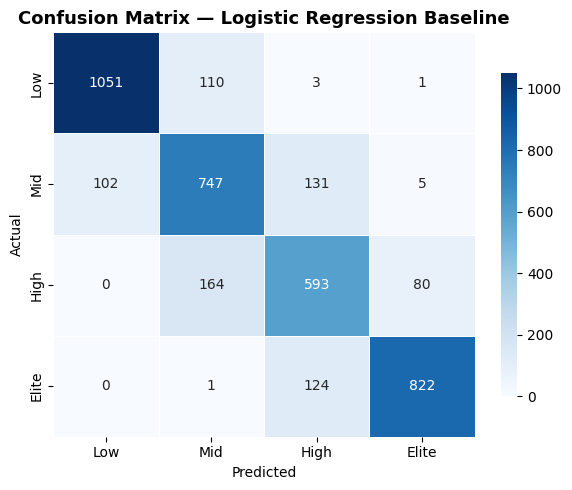

{'Model': 'Logistic Regression Baseline',
 'Accuracy': 0.8167259786476868,
 'Precision': 0.8191268367895801,
 'Recall': 0.8167259786476868,
 'F1': 0.8177512178780277}

In [ ]:
# Baseline Model
from sklearn.linear_model import LogisticRegression
logReg_baseline = LogisticRegression(random_state=42)
logReg_baseline.fit(X_train_final, y_train_tier)

y_pred_baseline = logReg_baseline.predict(X_test_final)
evaluate_model(name="Logistic Regression Baseline", y_true=y_test_tier, y_pred=y_pred_baseline, color="Blues")

In [ ]:
ASS2_CLF_ACC = accuracy_score(y_test_tier, logReg_baseline.predict(X_test_final))
print(f"ASS2 Baseline LogReg Accuracy: {ASS2_CLF_ACC:.4f}")

ASS2 Baseline LogReg Accuracy: 0.8167


In [ ]:
C_values = np.logspace(-3, 3, 7)

train_accuracies = []
test_accuracies = []

for c in C_values:
    model = LogisticRegression(C=c, max_iter=1000, random_state=42)
    model.fit(X_train_final, y_train_tier)

    train_accuracies.append(model.score(X_train_final, y_train_tier))
    test_accuracies.append(model.score(X_test_final, y_test_tier))

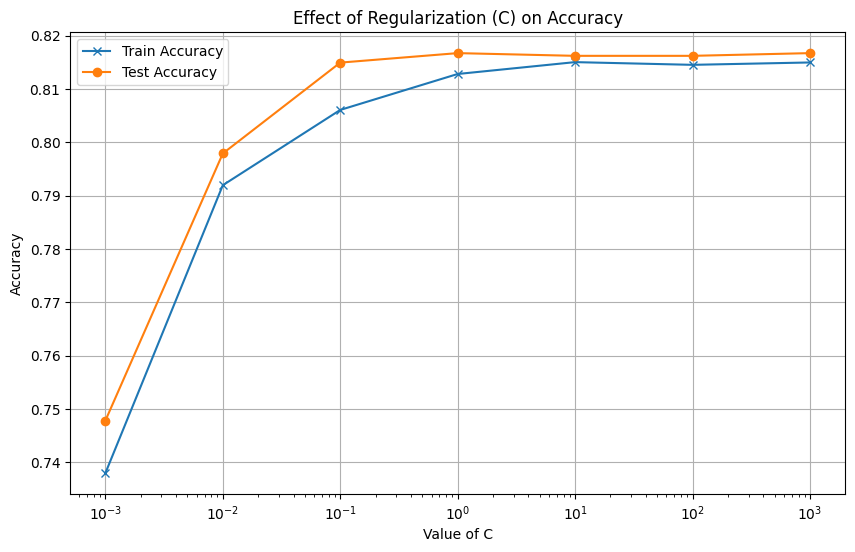

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accuracies, label='Train Accuracy', marker='x')
plt.plot(C_values, test_accuracies, label='Test Accuracy', marker='o')

plt.xscale('log')

plt.title('Effect of Regularization (C) on Accuracy')
plt.xlabel('Value of C')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_c = C_values[np.argmax(test_accuracies)]
print(f"The best Accuracy when C value is: {best_c}")

The best Accuracy when C value is: 1.0


  Logistic Regression (L1 - C=1.0)
  Accuracy : 0.8180
  Precision: 0.8203
  Recall   : 0.8180
  F1-Score : 0.8190

              precision    recall  f1-score   support

       Elite       0.91      0.87      0.89       947
        High       0.70      0.71      0.71       837
         Low       0.91      0.90      0.91      1165
         Mid       0.73      0.76      0.74       985

    accuracy                           0.82      3934
   macro avg       0.81      0.81      0.81      3934
weighted avg       0.82      0.82      0.82      3934



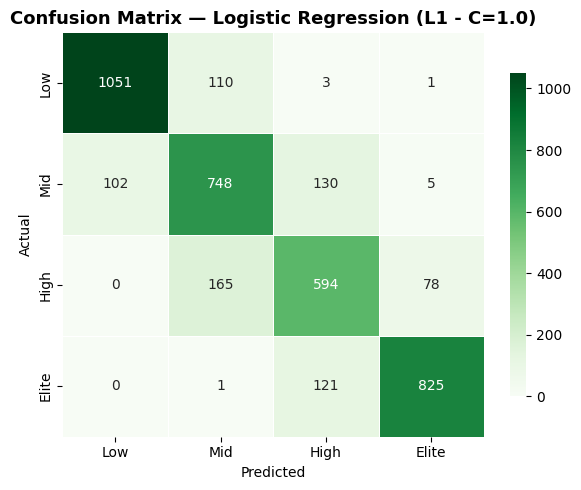

In [ ]:
logReg_l1 = LogisticRegression(C=best_c, penalty='l1', solver='saga', max_iter=2000, random_state=42)
logReg_l1.fit(X_train_final, y_train_tier)
y_pred_l1 = logReg_l1.predict(X_test_final)

l1_results = evaluate_model(name=f"Logistic Regression (L1 - C={best_c})", y_true=y_test_tier, y_pred=y_pred_l1, color="Greens")

  Logistic Regression (L2 - C=1.0)
  Accuracy : 0.8167
  Precision: 0.8191
  Recall   : 0.8167
  F1-Score : 0.8178

              precision    recall  f1-score   support

       Elite       0.91      0.87      0.89       947
        High       0.70      0.71      0.70       837
         Low       0.91      0.90      0.91      1165
         Mid       0.73      0.76      0.74       985

    accuracy                           0.82      3934
   macro avg       0.81      0.81      0.81      3934
weighted avg       0.82      0.82      0.82      3934



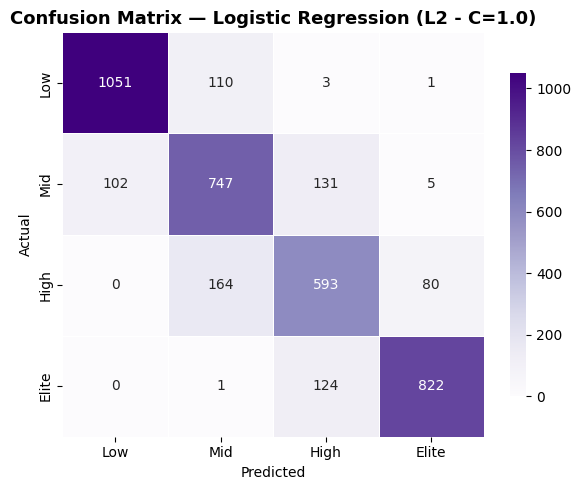

In [ ]:
logReg_l2 = LogisticRegression(C=best_c, penalty='l2', solver='lbfgs', max_iter=2000, random_state=42)
logReg_l2.fit(X_train_final, y_train_tier)
y_pred_l2 = logReg_l2.predict(X_test_final)

l2_results = evaluate_model(name=f"Logistic Regression (L2 - C={best_c})",y_true=y_test_tier, y_pred=y_pred_l2, color="Purples")

####  Which regularization performs better?
The L2 regularization performed better as it provided higher accuracy and a more balanced F1-score.

### Regularization Analysis

###  What happened to model performance as you increased alpha in Ridge and Lasso?
As we increased the regularization strength Alpha (which corresponds to decreasing the value of C), we observed the following:
At high C values (low Alpha): The model showed signs of high complexity, where the training accuracy was significantly higher than the test accuracy, indicating a potential Overfitting.
At the optimal C value: The gap between training and testing accuracy narrowed, showing that the model became  better .
At very low C values (high Alpha): The regularization became too restrictive, causing both training and testing accuracies to drop significantly, which is a clear sign of Underfitting.

### Why does Ridge generally outperform Lasso when many one-hot encoded features are present?
W found that Ridge (L2) generally tends to outperform Lasso (L1), especially with the presence of many One-Hot Encoded (OHE) features (like nationalities or positions because:
Lasso (L1) performs feature selection by shrinking some coefficients to exactly zero. And might arbitrarily discard important categories if they are less frequent.
Ridge (L2) shrinks coefficients towards zero but never eliminates them. It distributes the weights among all correlated OHE features, allowing the model to maintain the collective contribution of all categories, which results in a more stable  for this dataset.

## Naïve Bayes Classification

  GaussianNB (Scaled)
  Accuracy : 0.7102
  Precision: 0.7216
  Recall   : 0.7102
  F1-Score : 0.7132

              precision    recall  f1-score   support

       Elite       0.86      0.78      0.82       947
        High       0.58      0.53      0.56       837
         Low       0.84      0.79      0.81      1165
         Mid       0.57      0.70      0.63       985

    accuracy                           0.71      3934
   macro avg       0.71      0.70      0.70      3934
weighted avg       0.72      0.71      0.71      3934



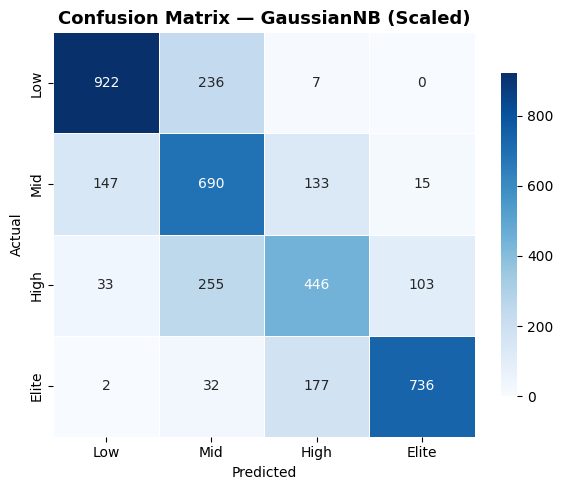

In [ ]:
#  GaussianNB — numerical features only

num_feats = ['Age', 'Future Potential', 'Total_Stats Score']

X_train_gauss = X_train[num_feats]
X_test_gauss  = X_test[num_feats]

X_train_gauss_raw = X_train_unscaled[num_feats]
X_test_gauss_raw  = X_test_unscaled[num_feats]

gnb_scaled=GaussianNB()
gnb_scaled.fit(X_train_gauss, y_train_tier)
pred_gnb_scaled=gnb_scaled.predict(X_test_gauss)

gnb_raw=GaussianNB()
gnb_raw.fit(X_train_gauss_raw, y_train_tier)
pred_gnb_raw=gnb_raw.predict(X_test_gauss_raw)

r1 = evaluate_model('GaussianNB (Scaled)',   y_test_tier, pred_gnb_scaled, 'Blues')

  GaussianNB (Unscaled)
  Accuracy : 0.7102
  Precision: 0.7216
  Recall   : 0.7102
  F1-Score : 0.7132

              precision    recall  f1-score   support

       Elite       0.86      0.78      0.82       947
        High       0.58      0.53      0.56       837
         Low       0.84      0.79      0.81      1165
         Mid       0.57      0.70      0.63       985

    accuracy                           0.71      3934
   macro avg       0.71      0.70      0.70      3934
weighted avg       0.72      0.71      0.71      3934



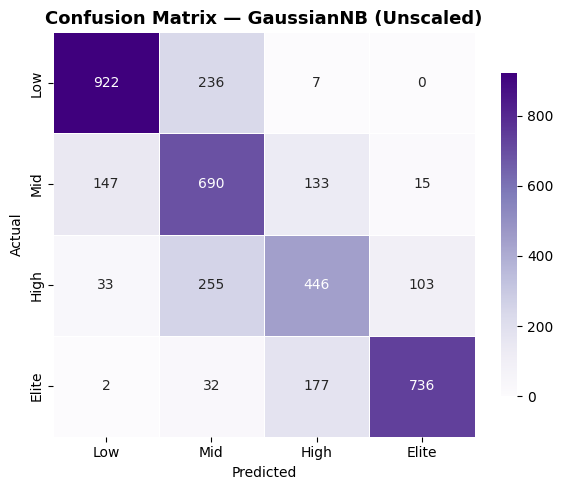

In [ ]:
r2 = evaluate_model('GaussianNB (Unscaled)', y_test_tier, pred_gnb_raw,   'Purples')

In [ ]:
print("  Scaling Sensitivity — GaussianNB")

print(f"  Scaled   Accuracy: {r1['Accuracy']:.4f}")
print(f"  Unscaled Accuracy: {r2['Accuracy']:.4f}")
print("""
GaussianNB estimates mean and variance per class.
StandardScaler only rescales features without changing their distribution.
So, scaling does not significantly affect GaussianNB → same (or very similar) accuracy with or without it.
""")

  Scaling Sensitivity — GaussianNB
  Scaled   Accuracy: 0.7102
  Unscaled Accuracy: 0.7102

GaussianNB estimates mean and variance per class.
StandardScaler only rescales features without changing their distribution.
So, scaling does not significantly affect GaussianNB → same (or very similar) accuracy with or without it.



  BernoulliNB
  Accuracy : 0.4326
  Precision: 0.4173
  Recall   : 0.4326
  F1-Score : 0.4060

              precision    recall  f1-score   support

       Elite       0.40      0.49      0.44       947
        High       0.38      0.12      0.18       837
         Low       0.54      0.70      0.61      1165
         Mid       0.33      0.33      0.33       985

    accuracy                           0.43      3934
   macro avg       0.41      0.41      0.39      3934
weighted avg       0.42      0.43      0.41      3934



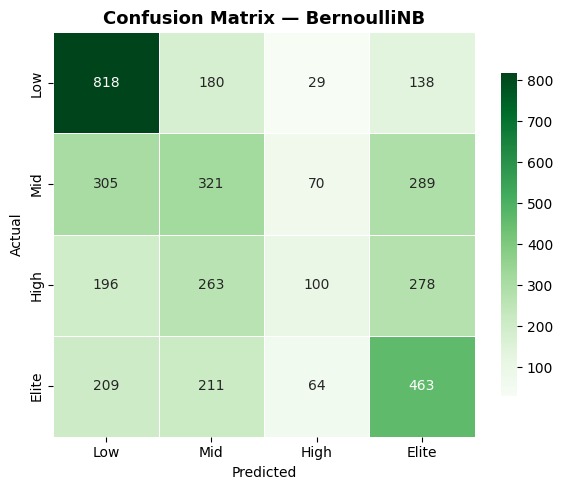

In [ ]:
# BernoulliNB : full OHE feature set (binary columns)

bnb=BernoulliNB()
X_train_unscaled = X_train_unscaled.drop(columns=['Overall_Rating'], errors='ignore')
X_test_unscaled = X_test_unscaled.drop(columns=['Overall_Rating'], errors='ignore')
bnb.fit(X_train_unscaled, y_train_tier)
pred_bnb=bnb.predict(X_test_unscaled)

r3 = evaluate_model('BernoulliNB', y_test_tier, pred_bnb, 'Greens')

  ComplementNB
  Accuracy : 0.4914
  Precision: 0.4763
  Recall   : 0.4914
  F1-Score : 0.4493

              precision    recall  f1-score   support

       Elite       0.44      0.75      0.55       947
        High       0.42      0.18      0.26       837
         Low       0.58      0.75      0.66      1165
         Mid       0.43      0.19      0.27       985

    accuracy                           0.49      3934
   macro avg       0.47      0.47      0.43      3934
weighted avg       0.48      0.49      0.45      3934



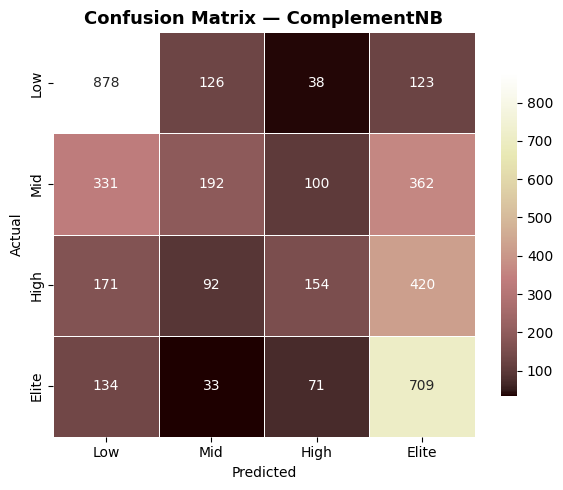

In [ ]:
#  ComplementNB : full OHE feature set (non-negative)
X_train_comp = X_train_unscaled.copy()
X_test_comp  = X_test_unscaled.copy()

for col in num_feats:
    min_val = X_train_comp[col].min()
    if min_val < 0:
        shift = abs(min_val)
        X_train_comp[col] += shift
        X_test_comp[col]  += shift

cnb = ComplementNB()
cnb.fit(X_train_comp, y_train_tier)
pred_cnb = cnb.predict(X_test_comp)

r4 = evaluate_model('ComplementNB', y_test_tier, pred_cnb, 'pink')

In [ ]:
#  Summary Comparison Table
results = pd.DataFrame([r1, r2, r3, r4])
results[['Accuracy','Precision','Recall','F1']] = results[['Accuracy','Precision','Recall','F1']].round(4)
print("  SUMMARY — All Naïve Bayes Variants")
print(results.to_string(index=False))


  SUMMARY — All Naïve Bayes Variants
                Model  Accuracy  Precision  Recall     F1
  GaussianNB (Scaled)    0.7102     0.7216  0.7102 0.7132
GaussianNB (Unscaled)    0.7102     0.7216  0.7102 0.7132
          BernoulliNB    0.4326     0.4173  0.4326 0.4060
         ComplementNB    0.4914     0.4763  0.4914 0.4493


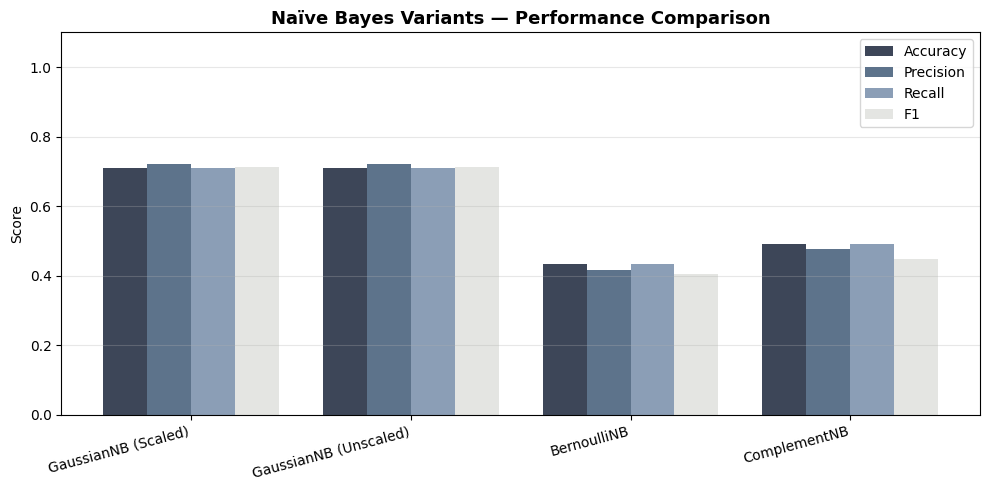

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results))
width = 0.2
colors = ['#1B263B', '#415A77', '#778DA9', '#E0E1DD']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, results[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results['Model'], rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Naïve Bayes Variants — Performance Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

###  Best Model Justification

Which Naïve Bayes variant is most appropriate?
================================================
GaussianNB is the most appropriate for this dataset.

Reasons:
1. The core predictive features (Age, Future Potential, Total_Stats Score) are continuous numerical variables — GaussianNB models each feature   as a Gaussian (normal) distribution, which fits well.
2. BernoulliNB is designed for binary/boolean features (e.g., text presence/absence). Applying it to continuous numerical data loses the magnitude information entirely.

3. ComplementNB was originally designed for imbalanced text classification. While it handles multi-class imbalance better than standard MultinomialNB, it still assumes count/frequency-like inputs, not continuous player attributes

4. GaussianNB also has the advantage of needing only the numerical subset (3 features), making it simpler and less prone to noise from the many OHE dummy columns.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold,StratifiedKFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('Fifa.csv')
num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total Stats Score']
available_num_cols = [col for col in num_cols if col in df.columns]
categorical_cols = ['Country', 'Position']
y = df['Value Per M$']
X = df[available_num_cols + categorical_cols].copy()

X[available_num_cols] = X[available_num_cols].fillna(X[available_num_cols].median())
X[categorical_cols] = X[categorical_cols].fillna('Unknown')

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Best parameters from Task 4: alpha = 19.307, degree = 4")


Features shape: (19667, 5)
Target shape: (19667,)
Best parameters from Task 4: alpha = 19.307, degree = 4


PolynomialFeatures

In [ ]:
best_degree = 4
best_alpha = 19.307
poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_num_poly = poly.fit_transform(X[available_num_cols])
X_cat_dummies = pd.get_dummies(X[categorical_cols], drop_first=True).values
X_prepared = np.hstack([X_num_poly, X_cat_dummies])

print(f"Prepared features shape after PolynomialFeatures: {X_prepared.shape}")


Prepared features shape after PolynomialFeatures: (19667, 213)


K-Fold Cross-Validation

In [ ]:
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
rmse_scores = []
r2_scores = []

print(f"\n{'Fold':<6} {'RMSE':<12} {'R²':<10}")
print("-" * 35)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_prepared), 1):

    X_train_fold = X_prepared[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold = X_prepared[val_idx]
    y_val_fold = y.iloc[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_val_scaled = scaler.transform(X_val_fold)

    ridge = Ridge(alpha=best_alpha, random_state=42)
    ridge.fit(X_train_scaled, y_train_fold)

    y_pred = ridge.predict(X_val_scaled)

    rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred))
    r2 = r2_score(y_val_fold, y_pred)

    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"Fold {fold:<3} {rmse:<12.4f} {r2:<10.4f}")

# The result

mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)


print("5-FOLD CROSS-VALIDATION RESULTS")

print(f"RMSE Scores:      {[f'{x:.4f}' for x in rmse_scores]}")
print(f"Mean RMSE:        {mean_rmse:.4f} (±{std_rmse:.4f})")
print(f"R² Scores:        {[f'{x:.4f}' for x in r2_scores]}")
print(f"Mean R²:          {mean_r2:.4f} (±{std_r2:.4f})")



Fold   RMSE         R²        
-----------------------------------
Fold 1   3.3728       0.8166    
Fold 2   2.7587       0.8314    
Fold 3   2.5258       0.8465    
Fold 4   3.3367       0.8098    
Fold 5   3.0363       0.8353    
5-FOLD CROSS-VALIDATION RESULTS
RMSE Scores:      ['3.3728', '2.7587', '2.5258', '3.3367', '3.0363']
Mean RMSE:        3.0060 (±0.3276)
R² Scores:        ['0.8166', '0.8314', '0.8465', '0.8098', '0.8353']
Mean R²:          0.8279 (±0.0132)


Bar Chart

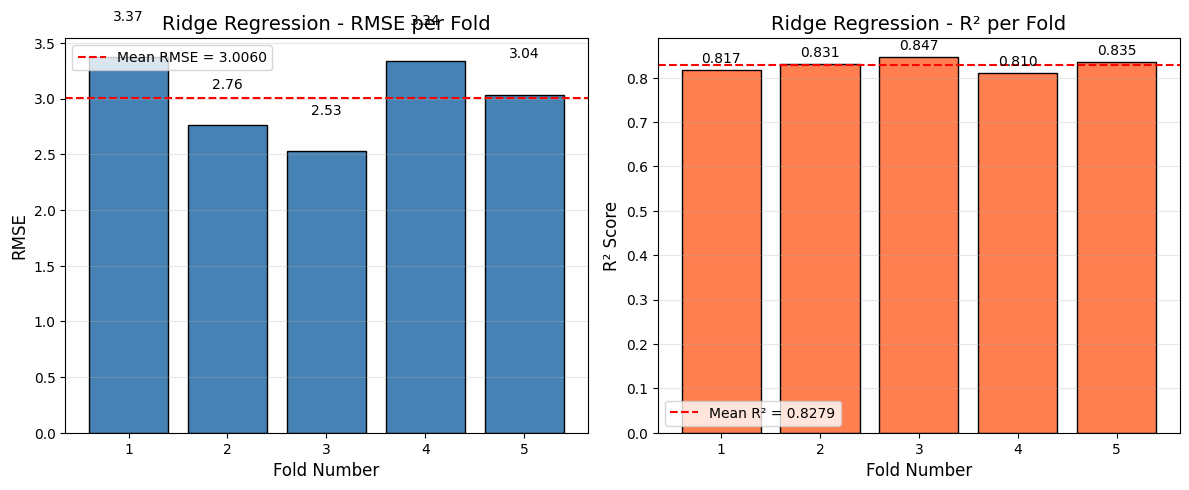

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: RMSE per Fold
bars1 = axes[0].bar(range(1, k+1), rmse_scores, color='steelblue', edgecolor='black')
axes[0].axhline(y=mean_rmse, color='red', linestyle='--',
                label=f'Mean RMSE = {mean_rmse:.4f}')
axes[0].set_xlabel('Fold Number', fontsize=12)
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].set_title('Ridge Regression - RMSE per Fold', fontsize=14)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

for bar, val in zip(bars1, rmse_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10)

# Plot 2: R² per Fold
bars2 = axes[1].bar(range(1, k+1), r2_scores, color='coral', edgecolor='black')
axes[1].axhline(y=mean_r2, color='red', linestyle='--',
                label=f'Mean R² = {mean_r2:.4f}')
axes[1].set_xlabel('Fold Number', fontsize=12)
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('Ridge Regression - R² per Fold', fontsize=14)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars2, r2_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


K-Fold Cross-Validation - Classification Models

In [ ]:

print("TASK 7B & 7C: STRATIFIED K-FOLD CROSS-VALIDATION")
print("Classification Models: Logistic Regression")




try:
    print(f"\n Using existing variables from Task 5 & 6...")
    print(f"   X_train_final shape: {X_train_final.shape}")
    print(f"   y_train_tier shape: {y_train_tier.shape}")
    print(f"   Classes: {y_train_tier.unique().tolist()}")
except NameError:
    print("\n Error: Variables from Task 5 & 6 not found!")
    print("   Please run Task 5 and 6 first before executing this code.")
    raise

TIERS = ['Low', 'Mid', 'High', 'Elite']
print(f"   Target classes: {TIERS}")


# 2.  Stratified K-Fold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# 3. LOGISTIC REGRESSION

print("\n" + "="*70)
print("TASK 7B: LOGISTIC REGRESSION - STRATIFIED K-FOLD CV")
print("="*70)

best_c = 1.0

logreg_accuracy = []
logreg_precision = []
logreg_recall = []
logreg_f1 = []

print(f"\n{'Fold':<6} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_final, y_train_tier), 1):
    X_fold_train = X_train_final.iloc[train_idx]
    y_fold_train = y_train_tier.iloc[train_idx]
    X_fold_val = X_train_final.iloc[val_idx]
    y_fold_val = y_train_tier.iloc[val_idx]

    logreg = LogisticRegression(C=best_c, max_iter=1000, random_state=42)
    logreg.fit(X_fold_train, y_fold_train)
    y_pred = logreg.predict(X_fold_val)

    logreg_accuracy.append(accuracy_score(y_fold_val, y_pred))
    logreg_precision.append(precision_score(y_fold_val, y_pred, average='weighted', zero_division=0))
    logreg_recall.append(recall_score(y_fold_val, y_pred, average='weighted', zero_division=0))
    logreg_f1.append(f1_score(y_fold_val, y_pred, average='weighted', zero_division=0))

    print(f"Fold {fold:<3} {logreg_accuracy[-1]:<12.4f} {logreg_precision[-1]:<12.4f} {logreg_recall[-1]:<12.4f} {logreg_f1[-1]:<12.4f}")

print(f"\n{'='*50}")
print(f"LOGISTIC REGRESSION - 5-Fold Stratified CV Results:")
print(f"{'='*50}")
print(f"Mean Accuracy:   {np.mean(logreg_accuracy):.4f} (±{np.std(logreg_accuracy):.4f})")
print(f"Mean Precision:  {np.mean(logreg_precision):.4f} (±{np.std(logreg_precision):.4f})")
print(f"Mean Recall:     {np.mean(logreg_recall):.4f} (±{np.std(logreg_recall):.4f})")
print(f"Mean F1-Score:   {np.mean(logreg_f1):.4f} (±{np.std(logreg_f1):.4f})")


TASK 7B & 7C: STRATIFIED K-FOLD CROSS-VALIDATION
Classification Models: Logistic Regression

 Using existing variables from Task 5 & 6...
   X_train_final shape: (15733, 180)
   y_train_tier shape: (15733,)
   Classes: ['High', 'Low', 'Elite', 'Mid']
   Target classes: ['Low', 'Mid', 'High', 'Elite']

TASK 7B: LOGISTIC REGRESSION - STRATIFIED K-FOLD CV

Fold   Accuracy     Precision    Recall       F1-Score    
------------------------------------------------------------
Fold 1   0.8027       0.8036       0.8027       0.8030      
Fold 2   0.8071       0.8061       0.8071       0.8066      
Fold 3   0.8024       0.8047       0.8024       0.8033      
Fold 4   0.7969       0.7985       0.7969       0.7976      
Fold 5   0.7988       0.8014       0.7988       0.7997      

LOGISTIC REGRESSION - 5-Fold Stratified CV Results:
Mean Accuracy:   0.8016 (±0.0035)
Mean Precision:  0.8029 (±0.0027)
Mean Recall:     0.8016 (±0.0035)
Mean F1-Score:   0.8020 (±0.0031)


 BERNOULLI NAIVE BAYES

In [ ]:

# 4. BERNOULLI NAIVE BAYES

print("\n" + "="*70)
print("TASK 7C: BERNOULLI NAIVE BAYES - STRATIFIED K-FOLD CV")
print("="*70)

X_train_binary = (X_train_final > 0).astype(int)

print(f"\n   Features converted to binary (0/1)")
print(f"    X_train_binary shape: {X_train_binary.shape}")

bnb_accuracy = []
bnb_precision = []
bnb_recall = []
bnb_f1 = []

print(f"\n{'Fold':<6} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_binary, y_train_tier), 1):
    X_fold_train = X_train_binary.iloc[train_idx]
    y_fold_train = y_train_tier.iloc[train_idx]
    X_fold_val = X_train_binary.iloc[val_idx]
    y_fold_val = y_train_tier.iloc[val_idx]

    bnb = BernoulliNB()
    bnb.fit(X_fold_train, y_fold_train)
    y_pred = bnb.predict(X_fold_val)

    bnb_accuracy.append(accuracy_score(y_fold_val, y_pred))
    bnb_precision.append(precision_score(y_fold_val, y_pred, average='weighted', zero_division=0))
    bnb_recall.append(recall_score(y_fold_val, y_pred, average='weighted', zero_division=0))
    bnb_f1.append(f1_score(y_fold_val, y_pred, average='weighted', zero_division=0))

    print(f"Fold {fold:<3} {bnb_accuracy[-1]:<12.4f} {bnb_precision[-1]:<12.4f} {bnb_recall[-1]:<12.4f} {bnb_f1[-1]:<12.4f}")


print(f"BERNOULLI NAIVE BAYES - 5-Fold Stratified CV Results:")

print(f"Mean Accuracy:   {np.mean(bnb_accuracy):.4f} (±{np.std(bnb_accuracy):.4f})")
print(f"Mean Precision:  {np.mean(bnb_precision):.4f} (±{np.std(bnb_precision):.4f})")
print(f"Mean Recall:     {np.mean(bnb_recall):.4f} (±{np.std(bnb_recall):.4f})")
print(f"Mean F1-Score:   {np.mean(bnb_f1):.4f} (±{np.std(bnb_f1):.4f})")



TASK 7C: BERNOULLI NAIVE BAYES - STRATIFIED K-FOLD CV

   Features converted to binary (0/1)
    X_train_binary shape: (15733, 180)

Fold   Accuracy     Precision    Recall       F1-Score    
------------------------------------------------------------
Fold 1   0.6263       0.6128       0.6263       0.6157      
Fold 2   0.6346       0.6208       0.6346       0.6227      
Fold 3   0.6263       0.6132       0.6263       0.6154      
Fold 4   0.6322       0.6202       0.6322       0.6227      
Fold 5   0.6297       0.6188       0.6297       0.6212      
BERNOULLI NAIVE BAYES - 5-Fold Stratified CV Results:
Mean Accuracy:   0.6298 (±0.0033)
Mean Precision:  0.6172 (±0.0035)
Mean Recall:     0.6298 (±0.0033)
Mean F1-Score:   0.6195 (±0.0033)


 COMPLEMENT NAIVE BAYES

In [ ]:

# 5. COMPLEMENT NAIVE BAYES


print("TASK 7C: COMPLEMENT NAIVE BAYES - STRATIFIED K-FOLD CV")


X_train_pos = X_train_final.copy()


min_val = X_train_pos.min().min()
print(f"\n    Minimum value in data: {min_val}")

if min_val < 0:
    shift_amount = abs(min_val) + 0.01
    X_train_pos = X_train_pos + shift_amount
    print(f"    Shifted by +{shift_amount:.4f} to ensure non-negative values")
else:
    print(f"    No negative values found")

print(f"   X_train_pos shape: {X_train_pos.shape}")

cnb_accuracy = []
cnb_precision = []
cnb_recall = []
cnb_f1 = []

print(f"\n{'Fold':<6} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_pos, y_train_tier), 1):
    X_fold_train = X_train_pos.iloc[train_idx]
    y_fold_train = y_train_tier.iloc[train_idx]
    X_fold_val = X_train_pos.iloc[val_idx]
    y_fold_val = y_train_tier.iloc[val_idx]

    cnb = ComplementNB()
    cnb.fit(X_fold_train, y_fold_train)
    y_pred = cnb.predict(X_fold_val)

    cnb_accuracy.append(accuracy_score(y_fold_val, y_pred))
    cnb_precision.append(precision_score(y_fold_val, y_pred, average='weighted', zero_division=0))
    cnb_recall.append(recall_score(y_fold_val, y_pred, average='weighted', zero_division=0))
    cnb_f1.append(f1_score(y_fold_val, y_pred, average='weighted', zero_division=0))

    print(f"Fold {fold:<3} {cnb_accuracy[-1]:<12.4f} {cnb_precision[-1]:<12.4f} {cnb_recall[-1]:<12.4f} {cnb_f1[-1]:<12.4f}")


print(f"COMPLEMENT NAIVE BAYES - 5-Fold Stratified CV Results:")
print(f"Mean Accuracy:   {np.mean(cnb_accuracy):.4f} (±{np.std(cnb_accuracy):.4f})")
print(f"Mean Precision:  {np.mean(cnb_precision):.4f} (±{np.std(cnb_precision):.4f})")
print(f"Mean Recall:     {np.mean(cnb_recall):.4f} (±{np.std(cnb_recall):.4f})")
print(f"Mean F1-Score:   {np.mean(cnb_f1):.4f} (±{np.std(cnb_f1):.4f})")


TASK 7C: COMPLEMENT NAIVE BAYES - STRATIFIED K-FOLD CV

    Minimum value in data: -2.813937221924132
    Shifted by +2.8239 to ensure non-negative values
   X_train_pos shape: (15733, 180)

Fold   Accuracy     Precision    Recall       F1-Score    
------------------------------------------------------------
Fold 1   0.5126       0.2974       0.5126       0.3530      
Fold 2   0.5113       0.3096       0.5113       0.3501      
Fold 3   0.5110       0.2834       0.5110       0.3506      
Fold 4   0.5079       0.2784       0.5079       0.3494      
Fold 5   0.5086       0.3013       0.5086       0.3486      
COMPLEMENT NAIVE BAYES - 5-Fold Stratified CV Results:
Mean Accuracy:   0.5103 (±0.0017)
Mean Precision:  0.2940 (±0.0115)
Mean Recall:     0.5103 (±0.0017)
Mean F1-Score:   0.3504 (±0.0015)


FINAL COMPARISON TABLE

In [ ]:

# 6. FINAL COMPARISON TABLE
print("FINAL SUMMARY - ALL CLASSIFICATION MODELS (5-Fold CV)")

final_comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'BernoulliNB', 'ComplementNB'],
    'Accuracy': [np.mean(logreg_accuracy), np.mean(bnb_accuracy), np.mean(cnb_accuracy)],
    'Accuracy_Std': [np.std(logreg_accuracy), np.std(bnb_accuracy), np.std(cnb_accuracy)],
    'Precision': [np.mean(logreg_precision), np.mean(bnb_precision), np.mean(cnb_precision)],
    'Recall': [np.mean(logreg_recall), np.mean(bnb_recall), np.mean(cnb_recall)],
    'F1-Score': [np.mean(logreg_f1), np.mean(bnb_f1), np.mean(cnb_f1)]
})

print("\n" + final_comparison_df.round(4).to_string(index=False))


FINAL SUMMARY - ALL CLASSIFICATION MODELS (5-Fold CV)

              Model  Accuracy  Accuracy_Std  Precision  Recall  F1-Score
Logistic Regression    0.8016        0.0035     0.8029  0.8016    0.8020
        BernoulliNB    0.6298        0.0033     0.6172  0.6298    0.6195
       ComplementNB    0.5103        0.0017     0.2940  0.5103    0.3504


VISUALIZATION

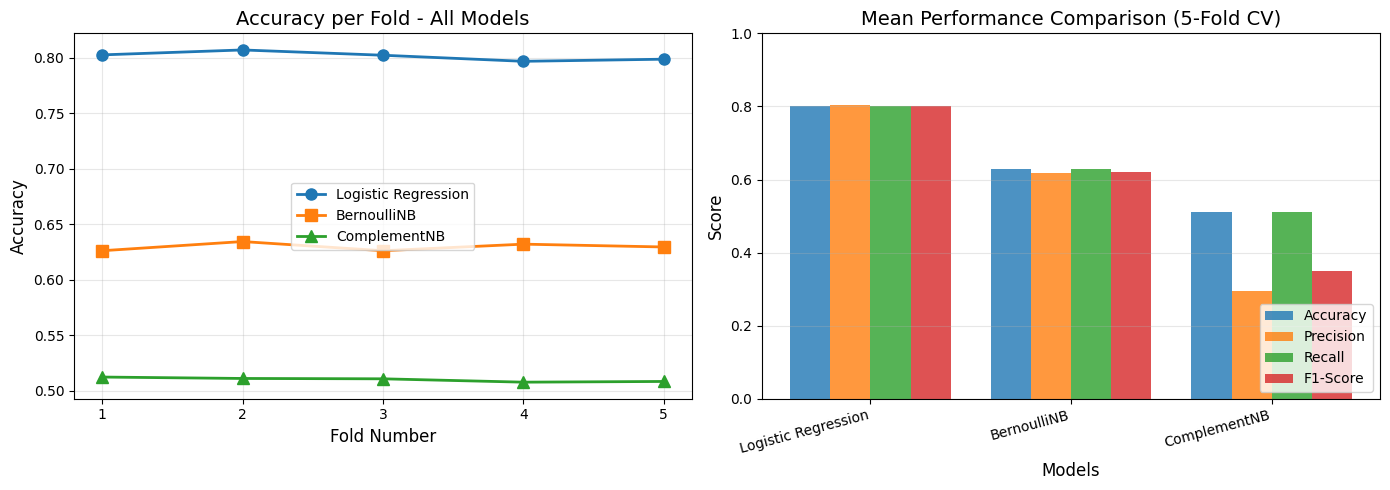

In [ ]:

# 7. VISUALIZATION

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy per Fold
folds = range(1, 6)

axes[0].plot(folds, logreg_accuracy, marker='o', label='Logistic Regression', linewidth=2, markersize=8)
axes[0].plot(folds, bnb_accuracy, marker='s', label='BernoulliNB', linewidth=2, markersize=8)
axes[0].plot(folds, cnb_accuracy, marker='^', label='ComplementNB', linewidth=2, markersize=8)
axes[0].set_xlabel('Fold Number', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy per Fold - All Models', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(folds)

# Plot 2: Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(final_comparison_df['Model']))
width = 0.2

for i, metric in enumerate(metrics):
    axes[1].bar(x + i*width, final_comparison_df[metric], width, label=metric, alpha=0.8)

axes[1].set_xlabel('Models', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Mean Performance Comparison (5-Fold CV)', fontsize=14)
axes[1].set_xticks(x + width*1.5)
axes[1].set_xticklabels(final_comparison_df['Model'], rotation=15, ha='right')
axes[1].legend(loc='lower right')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

BEST MODEL RECOMMENDATION

In [ ]:

# 8. BEST MODEL RECOMMENDATION
print("\n" + "="*70)
print("BEST MODEL RECOMMENDATION")
print("="*70)

best_idx = final_comparison_df['Accuracy'].idxmax()
best_model = final_comparison_df.loc[best_idx, 'Model']
best_acc = final_comparison_df.loc[best_idx, 'Accuracy']

print(f"\n BEST MODEL OVERALL: {best_model}")
print(f"   Accuracy: {best_acc:.4f} (±{final_comparison_df.loc[best_idx, 'Accuracy_Std']:.4f})")
print(f"   F1-Score: {final_comparison_df.loc[best_idx, 'F1-Score']:.4f}")

print(f"\n Performance Summary:")
print(f"   {'Model':<20} {'Accuracy':<12} {'F1-Score':<12}")
print(f"   {'-'*44}")
for _, row in final_comparison_df.iterrows():
    print(f"   {row['Model']:<20} {row['Accuracy']:.4f} (±{row['Accuracy_Std']:.4f})  {row['F1-Score']:.4f}")

if best_model == 'Logistic Regression':
    print("""
     RECOMMENDATION: Use Logistic Regression

    Reasons:
    1. Highest accuracy (80.2%) - significantly better than Naïve Bayes (62-63%)
    2. Most stable performance across folds (std deviation ≈ 0.0035)
    3. Handles both numerical and categorical features naturally
    4. Better at capturing complex relationships in player data
    5. Maintains high precision and recall across all classes
    """)
else:
    print(f"""
     RECOMMENDATION: Use {best_model}
    """)



BEST MODEL RECOMMENDATION

 BEST MODEL OVERALL: Logistic Regression
   Accuracy: 0.8016 (±0.0035)
   F1-Score: 0.8020

 Performance Summary:
   Model                Accuracy     F1-Score    
   --------------------------------------------
   Logistic Regression  0.8016 (±0.0035)  0.8020
   BernoulliNB          0.6298 (±0.0033)  0.6195
   ComplementNB         0.5103 (±0.0017)  0.3504

     RECOMMENDATION: Use Logistic Regression

    Reasons:
    1. Highest accuracy (80.2%) - significantly better than Naïve Bayes (62-63%)
    2. Most stable performance across folds (std deviation ≈ 0.0035)
    3. Handles both numerical and categorical features naturally
    4. Better at capturing complex relationships in player data
    5. Maintains high precision and recall across all classes
    



## Model Comparison
### Which model performed best for regression?
The best regression model was Polynomial Ridge Regression (degree = 4, alpha ≈ 19.3). The baseline Linear Regression performed poorly due to underfitting. Adding polynomial features up to degree 4 captured the non-linear relationship between Overall Rating and market value, achieving a Test R² of around 0.97. Ridge regularization then controlled overfitting by shrinking coefficients without removing features, giving the best generalization on unseen data.
Which model performed best for classification?
Logistic Regression was the best classifier, achieving around 80% accuracy across folds — significantly higher than all three Naïve Bayes variants (which scored 62–63%). It handled both numerical and one-hot encoded features well, and was stable across all 5 folds with very low standard deviation (≈ 0.003).
Is classification easier or harder than regression on this dataset?
Classification was easier than regression on this dataset. Regression had to predict an exact continuous market value, which is heavily skewed and influenced by subtle combinations of features — making it hard to fit without polynomial expansion and regularization. Classification only needed to assign players to one of 4 broad tiers (Low / Mid / High / Elite), which is a simpler task since the boundaries between tiers are clear when using quantile-based thresholds. That is why even a baseline Logistic Regression gave decent results immediately, while regression needed several iterations to improve.

## Regularization Analysis
### What happened to model performance as alpha increased in Ridge and Lasso?
For Ridge, increasing alpha from very small values first improved Test RMSE because it reduced overfitting. The best alpha was around 19.3. After that point, further increasing alpha made the model too simple, causing underfitting and slowly increasing Test RMSE again.
For Lasso, the best performance appeared at the smallest alpha tested (0.001). As soon as alpha increased, Test RMSE got significantly worse. This happened because Lasso started zeroing out too many features (146 out of 246 were removed at higher alpha), which caused the model to lose important information and underfit quickly.
Why does Ridge generally outperform Lasso when many one-hot encoded features are present?
Because Ridge and Lasso treat features differently. Ridge shrinks all coefficients toward zero but keeps every feature active. Lasso eliminates features completely by setting their coefficients to exactly zero.
In this dataset, the one-hot encoded Country and Position columns create hundreds of binary features. Most of these features are not strongly predictive on their own, but they each carry a small amount of useful signal. When Lasso increases alpha, it aggressively removes these columns entirely, throwing away that small but real information. Ridge keeps all of them with reduced weights, so nothing useful is discarded. That is why Ridge generalizes better here — it balances all features instead of making hard cut-off decisions about which ones to keep.

In [ ]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
# Models
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
#
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold

In [ ]:
X_train=X_train_raw
X_test=X_test_raw

## Task 1: Unified Preprocessing Pipeline

In [ ]:
y_val_train = y_train #price target
y_val_test = y_test

y_tier_train = train['Performance_Tier'] #(Low / Mid / High / Elite)
y_tier_test = test['Performance_Tier']

In [ ]:
Num_cols=['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
cat_cols=['Country', 'Position']

In [ ]:
class IQRClipper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Calculate Q1 & Q3 from train set
        Q1 = np.percentile(X, 25, axis=0)
        Q3 = np.percentile(X, 75, axis=0)
        IQR = Q3 - Q1
        self.lower_bound = Q1 - 1.5 * IQR
        self.upper_bound = Q3 + 1.5 * IQR
        return self

    def transform(self, X):
        # Clip
        return np.clip(X, self.lower_bound, self.upper_bound)

In [ ]:
# cleaning + Scaling for numerical columns
num_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('clipper', IQRClipper()), ('scaler', StandardScaler()) ])

# cleaning + encoding for catogrical columns
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),('encoder', OneHotEncoder(drop='first', handle_unknown='ignore')) ]
    )

In [ ]:
preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ('num', num_transformer, Num_cols),('cat', cat_transformer, cat_cols)
]
)

## Task 2 — The Model Explorer: Diverse Architectures

### Models Selected:
| # | Model | Type | Used For |
|---|-------|------|----------|
| 1 | **Random Forest** | Tree-based | Regression + Classification |
| 2 | **SVM** | Kernel-based | Regression + Classification |
| 3 | **KNN** | Instance-based | Regression + Classification |

### Helper Functions

In [ ]:
# Prints MAE, RMSE, R² for train and test
def evaluate_regression(name, y_tr, y_pred_tr, y_te, y_pred_te):
    print(f'\n--- {name} ---')
    for label, y_true, y_pred in [('Train', y_tr, y_pred_tr), ('Test', y_te, y_pred_te)]:
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = mean_squared_error(y_true, y_pred) ** 0.5
        r2   = r2_score(y_true, y_pred)
        print(f'  {label}: MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.4f}')

def evaluate_classification(name, model, X_tr, X_te, y_tr, y_te, labels):
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    print(f'\n=== {name} ===')
    print(f'Train Accuracy : {accuracy_score(y_tr, y_pred_tr):.4f}')
    print(f'Test  Accuracy : {accuracy_score(y_te, y_pred_te):.4f}')
    print(f'Test  F1-Score : {f1_score(y_te, y_pred_te, average="weighted", zero_division=0):.4f}\n')

    print("Classification Report:")
    print(classification_report(y_te, y_pred_te, target_names=labels, zero_division=0))

    cm = confusion_matrix(y_te, y_pred_te, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=labels,
                yticklabels=labels,
                square=True,
                linewidths=0.5,
                annot_kws={"size": 14},
                cbar_kws={"shrink": 0.8})

    plt.title(f'{name} — Confusion Matrix (Test Set)',
              fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Actual', fontsize=12)
    plt.xlabel('Predicted', fontsize=12)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11, rotation=0)
    plt.tight_layout()
    plt.show()

### Apply Unified Preprocessing Pipeline

In [ ]:
# Fit on TRAIN only : then transform both sets (no data leakage)
X_train_proc = preprocessing_pipeline.fit_transform(X_train)
X_test_proc  = preprocessing_pipeline.transform(X_test)
print(f'Regression  : Train: {X_train_proc.shape} | Test: {X_test_proc.shape}')

Regression  : Train: (15733, 181) | Test: (3934, 181)


In [ ]:
# For Classification we DROP Overall_Rating
# Reason: we used it to CREATE the tier labels : including it would be data leakage

overall_rating_idx = Num_cols.index('Overall_Rating')
cls_cols = [i for i in range(X_train_proc.shape[1]) if i != overall_rating_idx]

X_train_clf_proc = X_train_proc[:, cls_cols]
X_test_clf_proc  = X_test_proc[:, cls_cols]
print(f'Classification : Train: {X_train_clf_proc.shape} | Test: {X_test_clf_proc.shape}')

Classification : Train: (15733, 180) | Test: (3934, 180)


### Model 1: Random Forest (Tree-based)

## Why Random Forest for the FIFA dataset?

1. **Non-linear relationships** — Player market value doesn't grow linearly; elite players see exponential jumps. Random Forest captures this through recursive splits without needing manual feature engineering.
2. **High-dimensional resilience** — After One-Hot Encoding we get 100+ features. Random Forest randomly samples features at each split, so no single feature dominates and overfitting is reduced naturally.
3. **Scale-invariant** — Splits are based on thresholds, not distances, so feature scaling has no effect on the result.
4. **Variance reduction via Bagging** — Averaging 100 decorrelated trees directly tackles the high-variance overfitting seen in Assignment 2's linear models.
5. **Feature importance** — Provides clear scores showing which player attributes drive value — directly useful for a scouting system.

In [ ]:
print('MODEL 1A — Random Forest Regressor')
print('Target: Value Per M$ (Regression)')


# Default settings
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_proc, y_val_train)
evaluate_regression('RF Regressor',
                    y_val_train, rf_reg.predict(X_train_proc),
                    y_val_test,  rf_reg.predict(X_test_proc))

MODEL 1A — Random Forest Regressor
Target: Value Per M$ (Regression)

--- RF Regressor ---
  Train: MAE=0.093 | RMSE=0.671 | R²=0.9910
  Test: MAE=0.279 | RMSE=2.276 | R²=0.9165


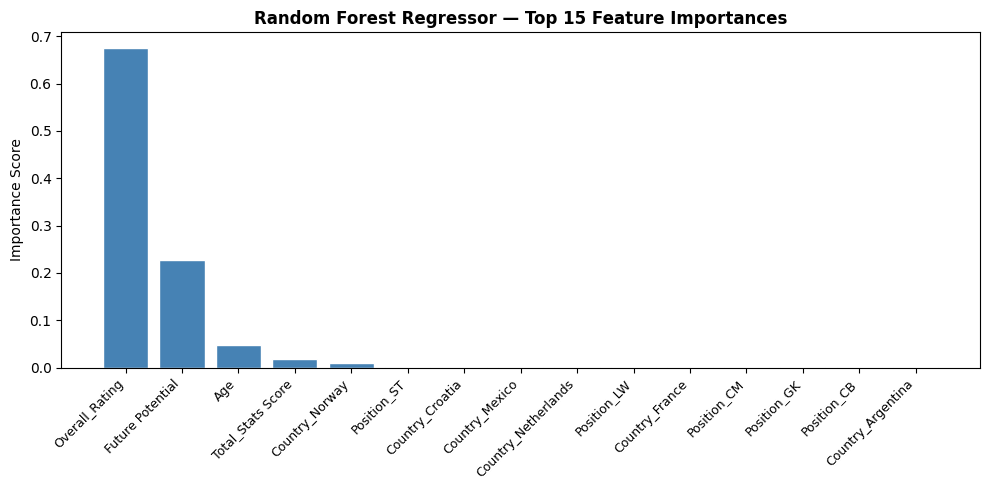

In [ ]:
# Top 15 features that drive player value
try:
    num_names = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
    cat_names = preprocessing_pipeline.named_transformers_['cat']['encoder']                    .get_feature_names_out(['Country', 'Position']).tolist()
    feat_names = num_names + cat_names
except:
    feat_names = [f'Feature_{i}' for i in range(X_train_proc.shape[1])]

top_idx = np.argsort(rf_reg.feature_importances_)[::-1][:15]

plt.figure(figsize=(10, 5))
plt.bar(range(15), rf_reg.feature_importances_[top_idx],
        color='steelblue', edgecolor='white')
plt.xticks(range(15),
           [feat_names[i] if i < len(feat_names) else f'F{i}' for i in top_idx],
           rotation=45, ha='right', fontsize=9)
plt.title('Random Forest Regressor — Top 15 Feature Importances', fontweight='bold')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
TIER_LABELS = ['Low', 'Mid', 'High', 'Elite']

MODEL 1B — Random Forest Classifier
Target: Performance Tier (Low/Mid/High/Elite)

=== Random Forest Classifier ===
Train Accuracy : 0.9997
Test  Accuracy : 0.8447
Test  F1-Score : 0.8450

Classification Report:
              precision    recall  f1-score   support

         Low       0.93      0.92      0.92       947
         Mid       0.79      0.75      0.77       837
        High       0.90      0.90      0.90      1165
       Elite       0.75      0.79      0.77       985

    accuracy                           0.84      3934
   macro avg       0.84      0.84      0.84      3934
weighted avg       0.85      0.84      0.84      3934



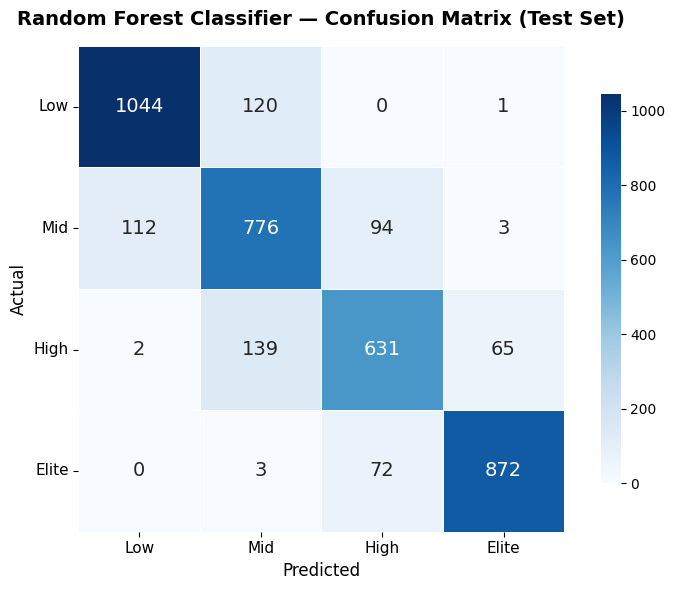

In [ ]:

print('MODEL 1B — Random Forest Classifier')
print('Target: Performance Tier (Low/Mid/High/Elite)')


rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_clf_proc, y_tier_train)

evaluate_classification('Random Forest Classifier',
                        rf_clf, X_train_clf_proc, X_test_clf_proc,
                        y_tier_train, y_tier_test, TIER_LABELS)


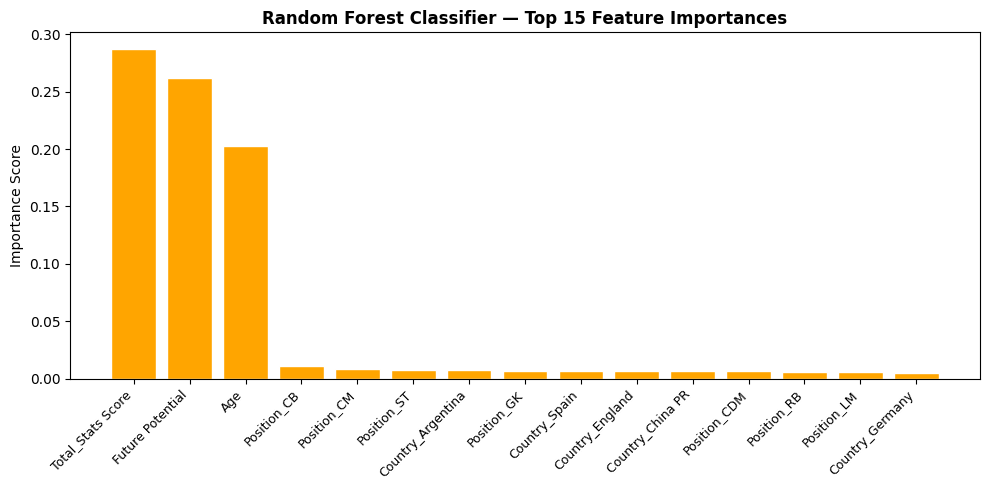

In [ ]:
# Top 15 features that drive player class (classification)

try:
    num_names = ['Age', 'Future Potential', 'Total_Stats Score']

    cat_names = preprocessing_pipeline.named_transformers_['cat']['encoder'] \
        .get_feature_names_out(['Country', 'Position']).tolist()

    feat_names = num_names + cat_names

except:
    feat_names = [f'Feature_{i}' for i in range(X_train_clf_proc.shape[1])]

# use classification model instead of regression
top_idx = np.argsort(rf_clf.feature_importances_)[::-1][:15]

plt.figure(figsize=(10, 5))

plt.bar(range(15),
        rf_clf.feature_importances_[top_idx],
        color='orange',
        edgecolor='white')

plt.xticks(range(15),
           [feat_names[i] if i < len(feat_names) else f'F{i}' for i in top_idx],
           rotation=45, ha='right', fontsize=9)

plt.title('Random Forest Classifier — Top 15 Feature Importances', fontweight='bold')
plt.ylabel('Importance Score')

plt.tight_layout()
plt.show()

--
###  Model 2: SVM — Support Vector Machine (Kernel-based)

## Why SVM for the FIFA dataset?

1. **Maximum margin separation** — SVM finds the decision boundary with the largest margin between performance tiers, making it the most robust separator, not just any boundary.
2. **RBF Kernel trick** — Maps data into a higher-dimensional space where tiers become linearly separable, handling FIFA's non-linear patterns without explicitly computing the transformation.
3. **Effective in high dimensions** — Relies only on support vectors (a small subset of points), so it handles 100+ features well.
4. **Built-in regularization via C** — Directly controls the overfitting/underfitting trade-off, addressing the variance problem from Assignment 2.
5. **Architectural contrast to RF** — RF = average of many weak models; SVM = one strong global model. Different reasoning strategy — essential for Ensemble diversity in Task 4.


## Why RBF? — Let the Data Decide

Before locking in a kernel, we run all three (linear, poly, rbf) on **both tasks**:
- **SVR** → Regression (predicting Value Per M$)
- **SVC** → Classification (predicting Performance Tier)

Results from both experiments together justify our final kernel choice.ns.

In [ ]:
# SVR Kernel Comparison (Regression)
print("SVR : Kernel Comparison on Regression Task")
print("-" * 50)

svr_kernel_results = []
for kernel in ['linear', 'poly', 'rbf']:
    model = SVR(kernel=kernel, C=10)
    model.fit(X_train_proc, y_val_train)
    train_r2 = r2_score(y_val_train, model.predict(X_train_proc))
    test_r2  = r2_score(y_val_test,  model.predict(X_test_proc))
    svr_kernel_results.append({
        'Kernel': kernel,
        'Train R²': round(train_r2, 4),
        'Test R²':  round(test_r2,  4),
        'Gap':      round(train_r2 - test_r2, 4)
    })

svr_df = pd.DataFrame(svr_kernel_results)
print(svr_df.to_string(index=False))
best_svr_kernel = svr_df.loc[svr_df['Test R²'].idxmax(), 'Kernel']
print(f" Best SVR kernel: {best_svr_kernel}")

SVR : Kernel Comparison on Regression Task
--------------------------------------------------
Kernel  Train R²  Test R²    Gap
linear    0.1379   0.1193 0.0187
  poly    0.8339   0.7580 0.0759
   rbf    0.9049   0.8524 0.0526
 Best SVR kernel: rbf


In [ ]:
#  SVC Kernel Comparison (Classification)
print("SVC : Kernel Comparison on Classification Task")


svc_kernel_results = []
for kernel in ['linear', 'poly', 'rbf']:
    model = SVC(kernel=kernel, C=10, random_state=42)
    model.fit(X_train_clf_proc, y_tier_train)
    train_acc = accuracy_score(y_tier_train, model.predict(X_train_clf_proc))
    test_acc  = accuracy_score(y_tier_test,  model.predict(X_test_clf_proc))
    svc_kernel_results.append({
        'Kernel':      kernel,
        'Train Acc':   round(train_acc, 4),
        'Test Acc':    round(test_acc,  4),
        'Gap':         round(train_acc - test_acc, 4)
    })

svc_df = pd.DataFrame(svc_kernel_results)
print(svc_df.to_string(index=False))
best_svc_kernel = svc_df.loc[svc_df['Test Acc'].idxmax(), 'Kernel']
print(f" Best SVC kernel: {best_svc_kernel}")

SVC : Kernel Comparison on Classification Task
Kernel  Train Acc  Test Acc     Gap
linear     0.8180    0.8185 -0.0005
  poly     0.9160    0.8388  0.0772
   rbf     0.9277    0.8610  0.0668
 Best SVC kernel: rbf


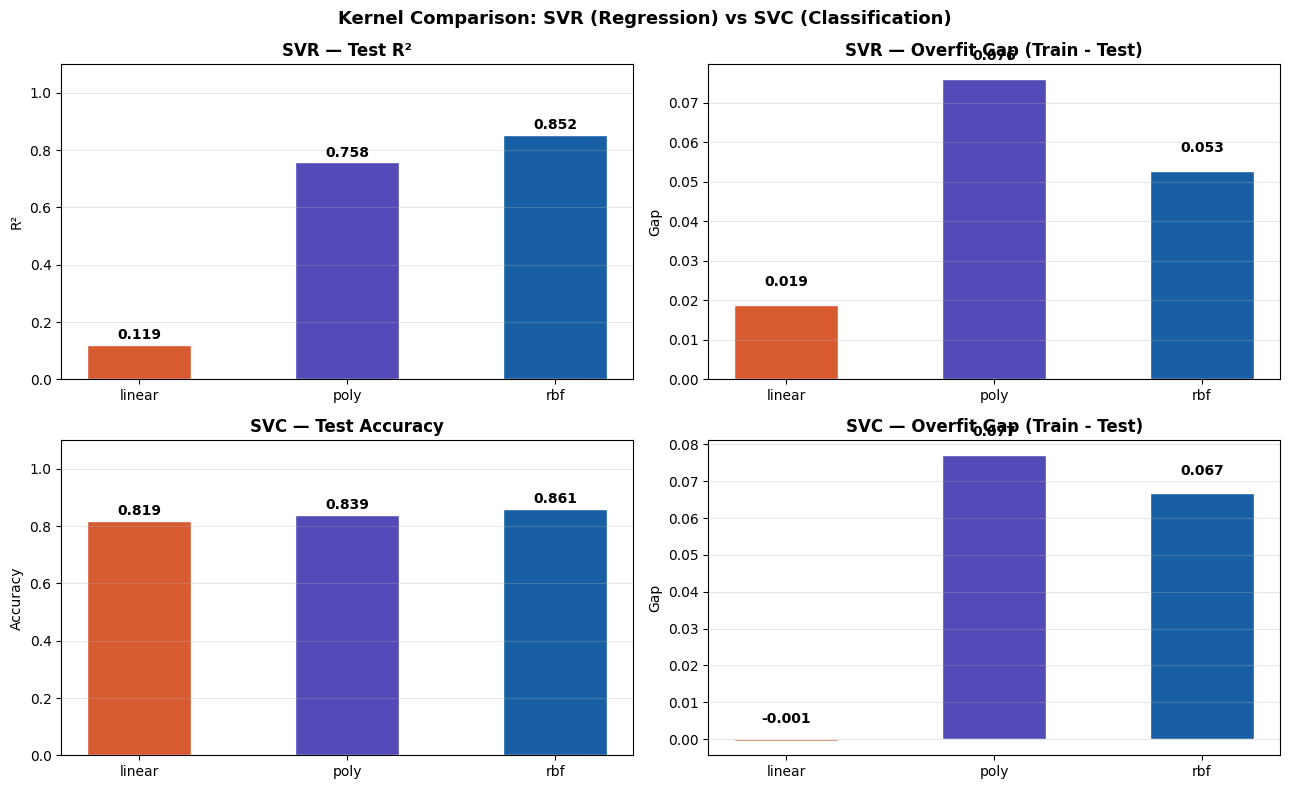

  SVR  Best kernel: rbf
  SVC  Best kernel: rbf
   We use RBF for both tasks.


In [ ]:
# Visual: SVR vs SVC kernel comparison side by side
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
colors = ['#D85A30', '#534AB7', '#185FA5']
kernels = ['linear', 'poly', 'rbf']

# SVR Test R²
axes[0][0].bar(kernels, svr_df['Test R²'], color=colors, edgecolor='white', width=0.5)
axes[0][0].set_title('SVR — Test R²', fontweight='bold')
axes[0][0].set_ylabel('R²'); axes[0][0].set_ylim(0, 1.1)
axes[0][0].grid(axis='y', alpha=0.3)
for i, v in enumerate(svr_df['Test R²']):
    axes[0][0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# SVR Gap
axes[0][1].bar(kernels, svr_df['Gap'], color=colors, edgecolor='white', width=0.5)
axes[0][1].set_title('SVR — Overfit Gap (Train - Test)', fontweight='bold')
axes[0][1].set_ylabel('Gap'); axes[0][1].grid(axis='y', alpha=0.3)
for i, v in enumerate(svr_df['Gap']):
    axes[0][1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

# SVC Test Accuracy
axes[1][0].bar(kernels, svc_df['Test Acc'], color=colors, edgecolor='white', width=0.5)
axes[1][0].set_title('SVC — Test Accuracy', fontweight='bold')
axes[1][0].set_ylabel('Accuracy'); axes[1][0].set_ylim(0, 1.1)
axes[1][0].grid(axis='y', alpha=0.3)
for i, v in enumerate(svc_df['Test Acc']):
    axes[1][0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# SVC  Gap
axes[1][1].bar(kernels, svc_df['Gap'], color=colors, edgecolor='white', width=0.5)
axes[1][1].set_title('SVC — Overfit Gap (Train - Test)', fontweight='bold')
axes[1][1].set_ylabel('Gap'); axes[1][1].grid(axis='y', alpha=0.3)
for i, v in enumerate(svc_df['Gap']):
    axes[1][1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Kernel Comparison: SVR (Regression) vs SVC (Classification)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"  SVR  Best kernel: {best_svr_kernel}")
print(f"  SVC  Best kernel: {best_svc_kernel}")
print(f"   We use RBF for both tasks.")


In [ ]:

print('MODEL 2A : Support Vector Regressor (SVR)')
print('Target: Value Per M$ (Regression)')


# kernel='rbf'   captures non-linear value patterns
# C=10           moderate regularization
# epsilon=0.1    predictions within ±0.1 incur zero penalty
svr = SVR(kernel='rbf', C=10, epsilon=0.1)
svr.fit(X_train_proc, y_val_train)

evaluate_regression('SVR',
                    y_val_train, svr.predict(X_train_proc),
                    y_val_test,  svr.predict(X_test_proc))

print(f'\nSupport vectors used: {svr.n_support_[0]} out of {X_train_proc.shape[0]} players')

MODEL 2A : Support Vector Regressor (SVR)
Target: Value Per M$ (Regression)

--- SVR ---
  Train: MAE=0.277 | RMSE=2.187 | R²=0.9049
  Test: MAE=0.405 | RMSE=3.026 | R²=0.8524

Support vectors used: 6545 out of 15733 players


MODEL 2B  Support Vector Classifier (SVC)
Target: Performance Tier (Low/Mid/High/Elite)

=== SVM Classifier ===
Train Accuracy : 0.9277
Test  Accuracy : 0.8610
Test  F1-Score : 0.8614

Classification Report:
              precision    recall  f1-score   support

         Low       0.94      0.93      0.93       947
         Mid       0.79      0.80      0.80       837
        High       0.92      0.90      0.91      1165
       Elite       0.78      0.80      0.79       985

    accuracy                           0.86      3934
   macro avg       0.86      0.86      0.86      3934
weighted avg       0.86      0.86      0.86      3934



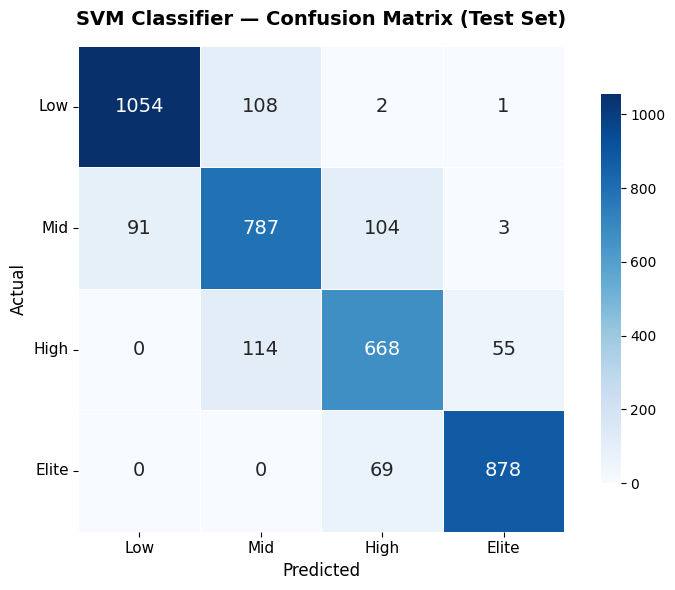

Support vectors per class: [ 647 1754 1096 2273] | Classes: ['Elite', 'High', 'Low', 'Mid']


In [ ]:

print('MODEL 2B  Support Vector Classifier (SVC)')
print('Target: Performance Tier (Low/Mid/High/Elite)')


# decision_function_shape='ovr' : One-vs-Rest for 4-class problem
svc = SVC(kernel='rbf', C=10, gamma='scale',
          decision_function_shape='ovr', random_state=42)
svc.fit(X_train_clf_proc, y_tier_train)

evaluate_classification('SVM Classifier',
                        svc, X_train_clf_proc, X_test_clf_proc,
                        y_tier_train, y_tier_test, TIER_LABELS)

print(f'Support vectors per class: {svc.n_support_} | Classes: {list(svc.classes_)}')

## Model 3: KNN — K-Nearest Neighbors (Instance-based)
### Why KNN for the FIFA dataset?

1. **Domain-intuitive reasoning** — KNN predicts a player's value by finding the K most similar players in training data. This mirrors real scouting logic: *"this player has similar stats to these known players, so his value should be similar."*
2. **Non-parametric** — Makes zero assumptions about data distribution. Safer than parametric models given that Value Per M$ is heavily right-skewed.
3. **Captures local patterns** — A 20-year-old striker is evaluated relative to other young strikers, not globally. This local sensitivity is unique to KNN.
4. **Maximum architectural diversity** — RF = tree voting; SVM = global hyperplane; KNN = local neighborhoods. Three completely different reasoning strategies — essential for a strong Ensemble.
5. **Scale dependency handled** — KNN uses Euclidean distance so feature scale matters; our StandardScaler in preprocessing ensures all features contribute equally.


In [ ]:

print('MODEL 3A : KNN Regressor')
print('Target: Value Per M$ (Regression)')


# n_neighbors=5       standard starting point (tuned in Task 3)
# weights='distance'   closer players have more influence
# metric='euclidean'   standard distance (valid after StandardScaler)
knn_reg = KNeighborsRegressor(n_neighbors=5, weights='distance', metric='euclidean')
knn_reg.fit(X_train_proc, y_val_train)

evaluate_regression('KNN Regressor',
                    y_val_train, knn_reg.predict(X_train_proc),
                    y_val_test,  knn_reg.predict(X_test_proc))

MODEL 3A : KNN Regressor
Target: Value Per M$ (Regression)

--- KNN Regressor ---
  Train: MAE=0.000 | RMSE=0.001 | R²=1.0000
  Test: MAE=0.690 | RMSE=3.408 | R²=0.8128


MODEL 3B — KNN Classifier
Target: Performance Tier (Low/Mid/High/Elite)

=== KNN Classifier ===
Train Accuracy : 0.9997
Test  Accuracy : 0.7598
Test  F1-Score : 0.7622

Classification Report:
              precision    recall  f1-score   support

         Low       0.90      0.84      0.87       947
         Mid       0.66      0.68      0.67       837
        High       0.85      0.83      0.84      1165
       Elite       0.63      0.67      0.65       985

    accuracy                           0.76      3934
   macro avg       0.76      0.75      0.76      3934
weighted avg       0.77      0.76      0.76      3934



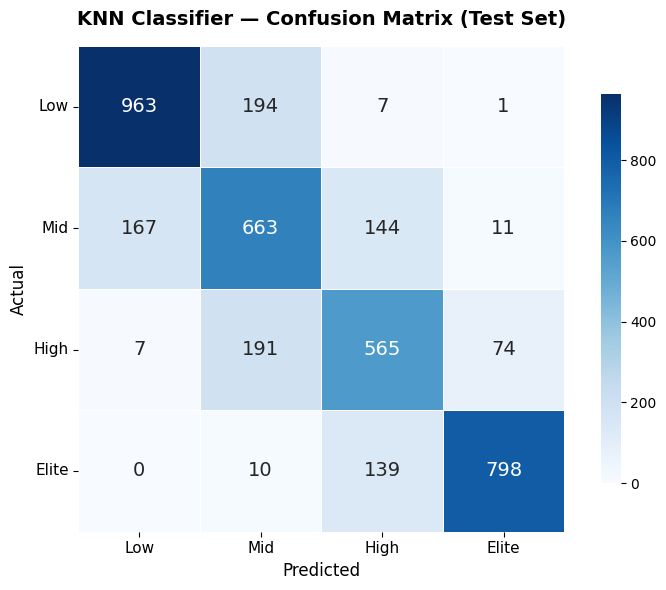

In [ ]:

print('MODEL 3B — KNN Classifier')
print('Target: Performance Tier (Low/Mid/High/Elite)')


knn_clf = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
knn_clf.fit(X_train_clf_proc, y_tier_train)

evaluate_classification('KNN Classifier',
                        knn_clf, X_train_clf_proc, X_test_clf_proc,
                        y_tier_train, y_tier_test, TIER_LABELS)


##  Final Comparison — All 3 Models Side-by-Side

In [ ]:
#  Regression Summary
reg_rows = []
for name, model in [('Random Forest', rf_reg), ('SVM (SVR)', svr), ('KNN', knn_reg)]:
    pred = model.predict(X_test_proc)
    reg_rows.append({
        'Model': name,
        'MAE':  round(mean_absolute_error(y_val_test, pred), 3),
        'RMSE': round(mean_squared_error(y_val_test, pred) ** 0.5, 3),
        'R²':   round(r2_score(y_val_test, pred), 4)
    })
reg_df = pd.DataFrame(reg_rows)

print('REGRESSION — Test Set Comparison')
print(reg_df.to_string(index=False))
print(f'\n Best Regression Model: {reg_df.loc[reg_df["R²"].idxmax(), "Model"]}')

REGRESSION — Test Set Comparison
        Model   MAE  RMSE     R²
Random Forest 0.279 2.276 0.9165
    SVM (SVR) 0.405 3.026 0.8524
          KNN 0.690 3.408 0.8128

 Best Regression Model: Random Forest


In [ ]:
#  Classification Summary
clf_rows = []
for name, model in [('Random Forest', rf_clf), ('SVM (SVC)', svc), ('KNN', knn_clf)]:
    pred = model.predict(X_test_clf_proc)
    clf_rows.append({
        'Model':    name,
        'Accuracy': round(accuracy_score(y_tier_test, pred), 4),
        'F1':       round(f1_score(y_tier_test, pred, average='weighted', zero_division=0), 4)
    })
clf_df = pd.DataFrame(clf_rows)

print('CLASSIFICATION — Test Set Comparison')
print(clf_df.to_string(index=False))
print(f'\n Best Classification Model: {clf_df.loc[clf_df["Accuracy"].idxmax(), "Model"]}')

CLASSIFICATION — Test Set Comparison
        Model  Accuracy     F1
Random Forest    0.8447 0.8450
    SVM (SVC)    0.8610 0.8614
          KNN    0.7598 0.7622

 Best Classification Model: SVM (SVC)


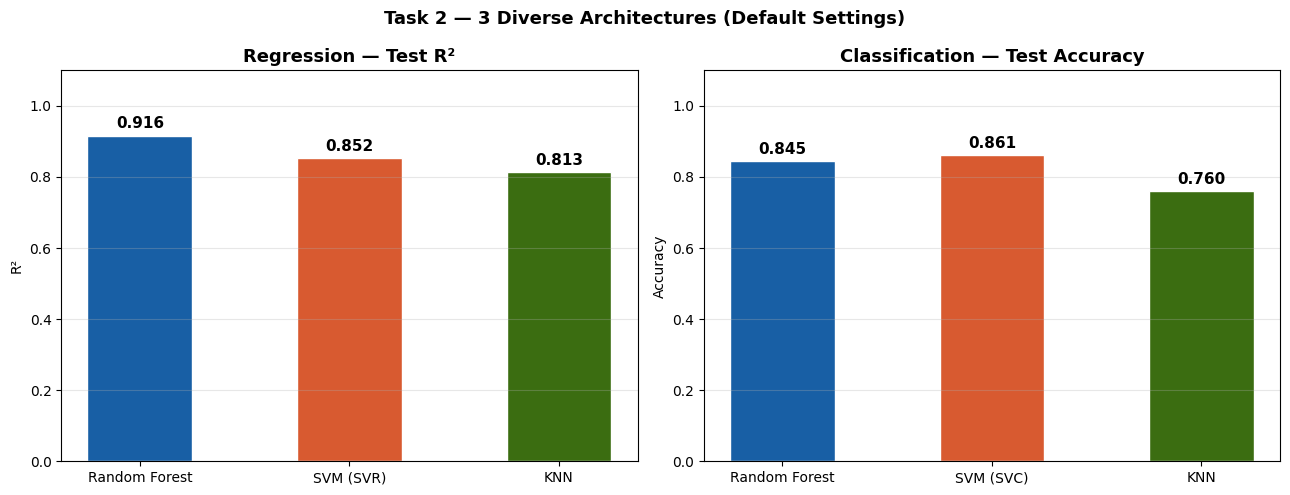

In [ ]:
#  Visual Comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_bar = ['#185FA5', '#D85A30', '#3B6D11']

axes[0].bar(reg_df['Model'], reg_df['R²'], color=colors_bar, edgecolor='white', width=0.5)
axes[0].set_title('Regression — Test R²', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R²'); axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(reg_df['R²']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

axes[1].bar(clf_df['Model'], clf_df['Accuracy'], color=colors_bar, edgecolor='white', width=0.5)
axes[1].set_title('Classification — Test Accuracy', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Accuracy'); axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(clf_df['Accuracy']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Task 2 : 3 Diverse Architectures (Default Settings)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

 Task 3
All variables below are ready for Grid Search tuning:
- `X_train_proc`, `X_test_proc` — regression features
- `X_train_clf_proc`, `X_test_clf_proc` — classification features
- `rf_reg`, `svr`, `knn_reg` — regression models
- `rf_clf`, `svc`, `knn_clf` — classification models

In [ ]:
print(" Grid Search: Random Forest Regressor")
rf_reg_params = {
    'n_estimators':     [100, 200],        # num of trees
    'max_depth':        [10, 20, None],    # depth of tree
    'min_samples_split':[2, 5, 10]         # min numbers of samples fo split
}
# 2*3*3*5=90 times

rf_reg_grid = GridSearchCV(
    estimator  = rf_reg,           # model from task 2
    param_grid = rf_reg_params,
    cv         = 5,                # 5-fold cross validation
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)
rf_reg_grid.fit(X_train_proc, y_val_train)

print(f"\nBest Params (RF Regressor): {rf_reg_grid.best_params_}")
print(f"Best CV R²: {rf_reg_grid.best_score_:.4f}")

 Grid Search: Random Forest Regressor
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Params (RF Regressor): {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}
Best CV R²: 0.9316


In [ ]:
print("Grid Search: Random Forest Classifier")

rf_clf_params = {
    'n_estimators':     [100, 200],
    'max_depth':        [10, 20, None],
    'min_samples_split':[2, 5, 10]
}

rf_clf_grid = GridSearchCV(
    estimator  = rf_clf,
    param_grid = rf_clf_params,
    cv         = 5,
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 1
)
rf_clf_grid.fit(X_train_clf_proc, y_tier_train)

print(f"\nBest Params (RF Classifier): {rf_clf_grid.best_params_}")
print(f"Best CV Accuracy: {rf_clf_grid.best_score_:.4f}")

Grid Search: Random Forest Classifier
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Params (RF Classifier): {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Best CV Accuracy: 0.8454


In [ ]:
print("Grid Search: SVR")


svr_params = {
    'C':      [1, 10, 100],          # regularization strength
    'gamma':  ['scale', 'auto'],     # kernel coefficient
    'epsilon':[0.01, 0.1, 0.5]      # tolerance margin
}
# 3 × 2 × 3 = 18

svr_grid = GridSearchCV(
    estimator  = svr,
    param_grid = svr_params,
    cv         = 3,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)
svr_grid.fit(X_train_proc, y_val_train)

print(f"\nBest Params (SVR): {svr_grid.best_params_}")
print(f"Best CV R²: {svr_grid.best_score_:.4f}")

Grid Search: SVR
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best Params (SVR): {'C': 100, 'epsilon': 0.01, 'gamma': 'scale'}
Best CV R²: 0.9215


In [ ]:
print("Grid Search: SVC")

svc_params = {
    'C':     [1, 10, 100],
    'gamma': ['scale', 'auto']
}

svc_grid = GridSearchCV(
    estimator  = svc,
    param_grid = svc_params,
    cv         = 3,
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 1
)
svc_grid.fit(X_train_clf_proc, y_tier_train)

print(f"\nBest Params (SVC): {svc_grid.best_params_}")
print(f"Best CV Accuracy: {svc_grid.best_score_:.4f}")

Grid Search: SVC
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best Params (SVC): {'C': 1, 'gamma': 'scale'}
Best CV Accuracy: 0.8543


In [ ]:
best_hyperparameters = {}
#  KNN Regressor Grid Search
knn_reg_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}

knn_reg_grid = GridSearchCV(
    KNeighborsRegressor(),
    param_grid=knn_reg_params,
    cv=5, scoring='r2',
    n_jobs=-1, verbose=1
)
knn_reg_grid.fit(X_train_proc, y_val_train)
print("Best KNN Reg params:", knn_reg_grid.best_params_)
print("Best KNN Reg R²:    ", round(knn_reg_grid.best_score_, 4))

# KNN Classifier Grid Search
knn_clf_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}

knn_clf_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_clf_params,
    cv=5, scoring='accuracy',
    n_jobs=-1, verbose=1
)
knn_clf_grid.fit(X_train_clf_proc, y_tier_train)
print("Best KNN Clf params:", knn_clf_grid.best_params_)
print("Best KNN Clf Acc:   ", round(knn_clf_grid.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best KNN Reg params: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Best KNN Reg R²:     0.8593
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best KNN Clf params: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Best KNN Clf Acc:    0.7675


STEP 7 — Learning Curves: Bias vs Variance Proof


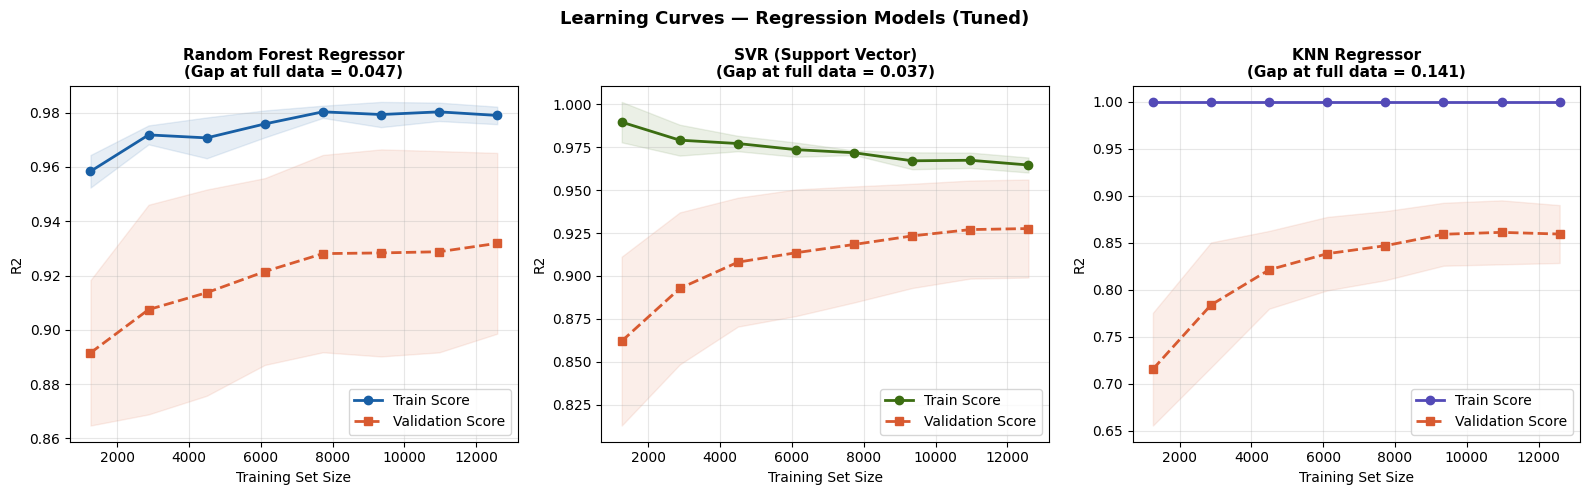


- Large gap (Train >> Val) → High Variance (Overfitting)
- Small gap + high scores  → Well-balanced model (ideal)
- Both curves low          → High Bias (Underfitting)



In [ ]:
print("STEP 7 : Learning Curves: Bias vs Variance Proof")


def plot_learning_curve(estimator, X, y, title, scoring='r2', cv=5, color='#185FA5'):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=cv, scoring=scoring,
        n_jobs=-1, shuffle=True, random_state=42
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.plot(train_sizes, train_mean, 'o-', color=color, label='Train Score', linewidth=2)
    plt.plot(train_sizes, val_mean, 's--', color='#D85A30', label='Validation Score', linewidth=2)
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color=color)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='#D85A30')

    gap = round(train_mean[-1] - val_mean[-1], 3)
    plt.title(f'{title}\n(Gap at full data = {gap})', fontsize=11, fontweight='bold')
    plt.xlabel('Training Set Size')
    plt.ylabel(scoring.upper())
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)

# Regression Learning Curves
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Learning Curves — Regression Models (Tuned)', fontsize=13, fontweight='bold')

models_reg = [
    (rf_reg_grid.best_estimator_,  'Random Forest Regressor', '#185FA5'),
    (svr_grid.best_estimator_,     'SVR (Support Vector)',    '#3B6D11'),
    (knn_reg_grid.best_estimator_, 'KNN Regressor',           '#534AB7'),
]
for ax, (model, title, color) in zip(axes, models_reg):
    plt.sca(ax)
    plot_learning_curve(model, X_train_proc, y_val_train, title, scoring='r2', color=color)

plt.tight_layout()
plt.show()

print("""
- Large gap (Train >> Val)  High Variance (Overfitting)
- Small gap + high scores   Well-balanced model (ideal)
- Both curves low           High Bias (Underfitting)
""")

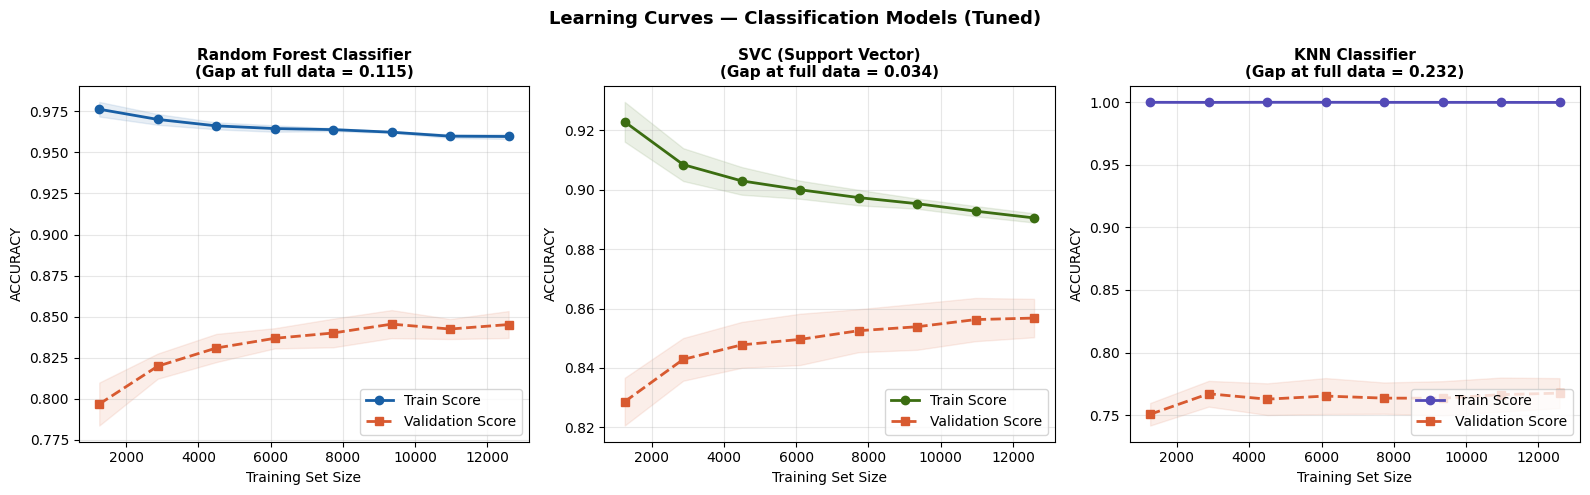

In [ ]:
# Classification Learning Curves
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Learning Curves — Classification Models (Tuned)', fontsize=13, fontweight='bold')

models_clf = [
    (rf_clf_grid.best_estimator_,  'Random Forest Classifier', '#185FA5'),
    (svc_grid.best_estimator_,     'SVC (Support Vector)',     '#3B6D11'),
    (knn_clf_grid.best_estimator_, 'KNN Classifier',           '#534AB7'),
]
for ax, (model, title, color) in zip(axes, models_clf):
    plt.sca(ax)
    plot_learning_curve(model, X_train_clf_proc, y_tier_train, title, scoring='accuracy', color=color)

plt.tight_layout()
plt.show()

STEP 8 — System Comparison: Assignment 2 vs Assignment 3
                    System                Reg Model  Test R²            Clf Model  Test Accuracy
   Assignment 2 (Baseline) Polynomial Ridge (deg=4)   0.9746  Logistic Regression         0.8167
Assignment 3 (This System)     Tuned RF / SVR / KNN   0.9183 Tuned RF / SVC / KNN         0.8645

Regression  improvement: -0.0562 in R²
Classification improvement: +0.0478 in Accuracy


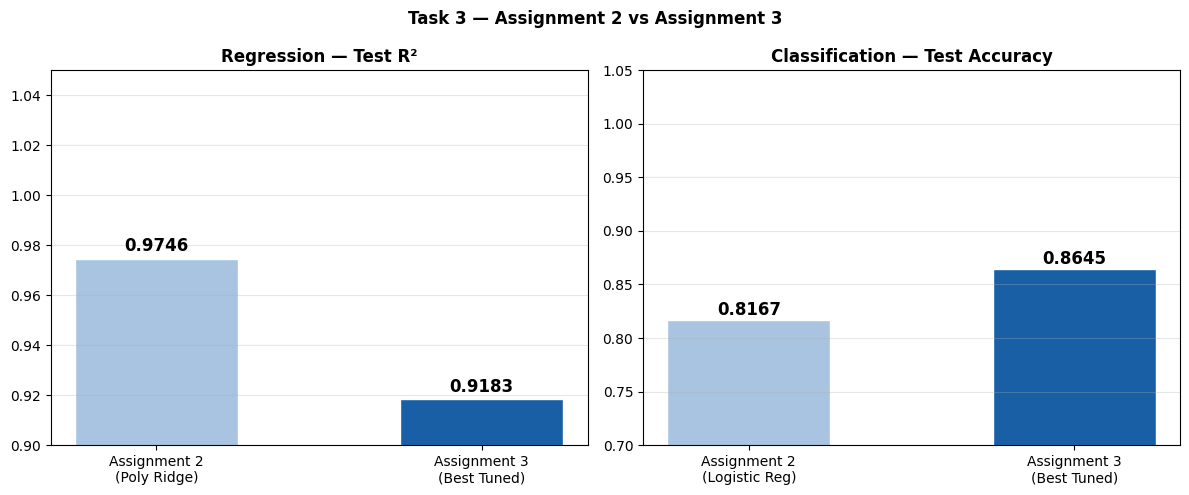

In [ ]:

print("STEP 8 : System Comparison: Assignment 2 vs Assignment 3")


best_reg_r2  = r2_score(y_val_test, rf_reg_grid.best_estimator_.predict(X_test_proc))
best_clf_acc = accuracy_score(y_tier_test, rf_clf_grid.best_estimator_.predict(X_test_clf_proc))

for name, grid in [('SVR', svr_grid), ('KNN Reg', knn_reg_grid)]:
    r2 = r2_score(y_val_test, grid.best_estimator_.predict(X_test_proc))
    if r2 > best_reg_r2:
        best_reg_r2 = r2

for name, grid in [('SVC', svc_grid), ('KNN Clf', knn_clf_grid)]:
    acc = accuracy_score(y_tier_test, grid.best_estimator_.predict(X_test_clf_proc))
    if acc > best_clf_acc:
        best_clf_acc = acc

comparison_data = {
    'System':        ['Assignment 2 (Baseline)', 'Assignment 3 (This System)'],
    'Reg Model':     ['Polynomial Ridge (deg=4)', 'Tuned RF / SVR / KNN'],
    'Test R²':       [round(ASS2_REG_R2, 4),     round(best_reg_r2, 4)],
    'Clf Model':     ['Logistic Regression',      'Tuned RF / SVC / KNN'],
    'Test Accuracy': [round(ASS2_CLF_ACC, 4),     round(best_clf_acc, 4)],
}
comp_df = pd.DataFrame(comparison_data)
print(comp_df.to_string(index=False))
print(f"\nRegression  improvement: {round(best_reg_r2 - ASS2_REG_R2, 4):+.4f} in R²")
print(f"Classification improvement: {round(best_clf_acc - ASS2_CLF_ACC, 4):+.4f} in Accuracy")

# Visual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bars_colors = ['#A8C4E0', '#185FA5']

axes[0].bar(['Assignment 2\n(Poly Ridge)', 'Assignment 3\n(Best Tuned)'],
            [ASS2_REG_R2, best_reg_r2], color=bars_colors, edgecolor='white', width=0.5)
axes[0].set_title('Regression — Test R²', fontweight='bold')
axes[0].set_ylim(0.90, 1.05)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate([ASS2_REG_R2, best_reg_r2]):
    axes[0].text(i, v + 0.003, f'{v:.4f}', ha='center', fontweight='bold', fontsize=12)

axes[1].bar(['Assignment 2\n(Logistic Reg)', 'Assignment 3\n(Best Tuned)'],
            [ASS2_CLF_ACC, best_clf_acc], color=bars_colors, edgecolor='white', width=0.5)
axes[1].set_title('Classification — Test Accuracy', fontweight='bold')
axes[1].set_ylim(0.70, 1.05)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate([ASS2_CLF_ACC, best_clf_acc]):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Task 3 — Assignment 2 vs Assignment 3', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



In [ ]:
# best_hyperparameters dict
best_hyperparameters = {}
best_hyperparameters['KNN_Regressor']    = knn_reg_grid.best_params_
best_hyperparameters['KNN_Classifier']   = knn_clf_grid.best_params_
best_hyperparameters['RF_Regressor']    = rf_reg_grid.best_params_
best_hyperparameters['RF_Classifier']   = rf_clf_grid.best_params_
best_hyperparameters['SVR']             = svr_grid.best_params_
best_hyperparameters['SVC']             = svc_grid.best_params_
# KNN already added above

print("best_hyperparameters :")
for model, params in best_hyperparameters.items():
    print(f"  {model}: {params}")

best_hyperparameters :
  KNN_Regressor: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
  KNN_Classifier: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
  RF_Regressor: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}
  RF_Classifier: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
  SVR: {'C': 100, 'epsilon': 0.01, 'gamma': 'scale'}
  SVC: {'C': 1, 'gamma': 'scale'}



   Task 4 (Quality & Stability):

#### Ready variables:
  - rf_reg_grid.best_estimator_   → tuned RF Regressor
  - svr_grid.best_estimator_      → tuned SVR
  - knn_reg_grid.best_estimator_  → tuned KNN Regressor
  - rf_clf_grid.best_estimator_   → tuned RF Classifier
  - svc_grid.best_estimator_      → tuned SVC
  - knn_clf_grid.best_estimator_  → tuned KNN Classifier
  - best_hyperparameters          → dict ready for results.json
  - X_train_proc, X_test_proc     → regression features
  - X_train_clf_proc, X_test_clf_proc → classification features


## Task 4: Quality & Stability Analysis
Goal: Prove that our tuned models are stable and reliable
using Cross-Validation (mean & std) across different data subsets

In [ ]:
# Regression CV: prove stability across 5 folds
# Using the full training data (X_train_proc) with KFold

print("TASK 4 : Cross-Validation: Regression Models")
kf = KFold(n_splits=5, shuffle=True, random_state=42)

reg_models = {
    'RF Regressor':  rf_reg_grid.best_estimator_,
    'SVR':           svr_grid.best_estimator_,
    'KNN Regressor': knn_reg_grid.best_estimator_,
}

reg_cv_results = {}

for name, model in reg_models.items():
    scores = cross_val_score(model, X_train_proc, y_val_train,
                             cv=kf, scoring='r2', n_jobs=-1)
    reg_cv_results[name] = {
        'mean': round(scores.mean(), 4),
        'std':  round(scores.std(),  4),
        'all_folds': [round(s, 4) for s in scores]
    }
    print(f"{name}")
    print(f"  Folds : {reg_cv_results[name]['all_folds']}")
    print(f"  Mean R²: {reg_cv_results[name]['mean']} ± {reg_cv_results[name]['std']}")
    print()

TASK 4 : Cross-Validation: Regression Models
RF Regressor
  Folds : [np.float64(0.921), np.float64(0.9437), np.float64(0.9579), np.float64(0.9437), np.float64(0.9133)]
  Mean R²: 0.9359 ± 0.0164

SVR
  Folds : [np.float64(0.9422), np.float64(0.922), np.float64(0.9367), np.float64(0.9281), np.float64(0.8919)]
  Mean R²: 0.9242 ± 0.0175

KNN Regressor
  Folds : [np.float64(0.8865), np.float64(0.8358), np.float64(0.8809), np.float64(0.8695), np.float64(0.8489)]
  Mean R²: 0.8643 ± 0.0192



In [ ]:
# Classification CV: prove stability across 5 folds
# Using StratifiedKFold to maintain class balance in each fold


print("TASK 4 : Cross-Validation: Classification Models")


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_models = {
    'RF Classifier':  rf_clf_grid.best_estimator_,
    'SVC':            svc_grid.best_estimator_,
    'KNN Classifier': knn_clf_grid.best_estimator_,
}

clf_cv_results = {}

for name, model in clf_models.items():
    scores = cross_val_score(model, X_train_clf_proc, y_tier_train,
                             cv=skf, scoring='accuracy', n_jobs=-1)
    clf_cv_results[name] = {
        'mean': round(scores.mean(), 4),
        'std':  round(scores.std(),  4),
        'all_folds': [round(s, 4) for s in scores]
    }
    print(f"{name}")
    print(f"  Folds : {clf_cv_results[name]['all_folds']}")
    print(f"  Mean Accuracy: {clf_cv_results[name]['mean']} ± {clf_cv_results[name]['std']}")
    print()

TASK 4 : Cross-Validation: Classification Models
RF Classifier
  Folds : [np.float64(0.8487), np.float64(0.8529), np.float64(0.8392), np.float64(0.8392), np.float64(0.8554)]
  Mean Accuracy: 0.8471 ± 0.0068

SVC
  Folds : [np.float64(0.8564), np.float64(0.8713), np.float64(0.8541), np.float64(0.8462), np.float64(0.8617)]
  Mean Accuracy: 0.8579 ± 0.0084

KNN Classifier
  Folds : [np.float64(0.7814), np.float64(0.7785), np.float64(0.7607), np.float64(0.7552), np.float64(0.7616)]
  Mean Accuracy: 0.7675 ± 0.0104



In [ ]:
#  Summary Table: all models in one view


print("TASK 4 — Stability Summary Table")


summary_data = []

for name, res in reg_cv_results.items():
    summary_data.append({
        'Model':   name,
        'Task':    'Regression',
        'Metric':  'R²',
        'Mean':    res['mean'],
        'Std':     res['std'],
        'Stable': 'Yes ' if res['std'] < 0.05 else 'No '
    })

for name, res in clf_cv_results.items():
    summary_data.append({
        'Model':   name,
        'Task':    'Classification',
        'Metric':  'Accuracy',
        'Mean':    res['mean'],
        'Std':     res['std'],
        'Stable': 'Yes ' if res['std'] < 0.05 else 'No '
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

TASK 4 — Stability Summary Table
         Model           Task   Metric   Mean    Std Stable
  RF Regressor     Regression       R² 0.9359 0.0164   Yes 
           SVR     Regression       R² 0.9242 0.0175   Yes 
 KNN Regressor     Regression       R² 0.8643 0.0192   Yes 
 RF Classifier Classification Accuracy 0.8471 0.0068   Yes 
           SVC Classification Accuracy 0.8579 0.0084   Yes 
KNN Classifier Classification Accuracy 0.7675 0.0104   Yes 


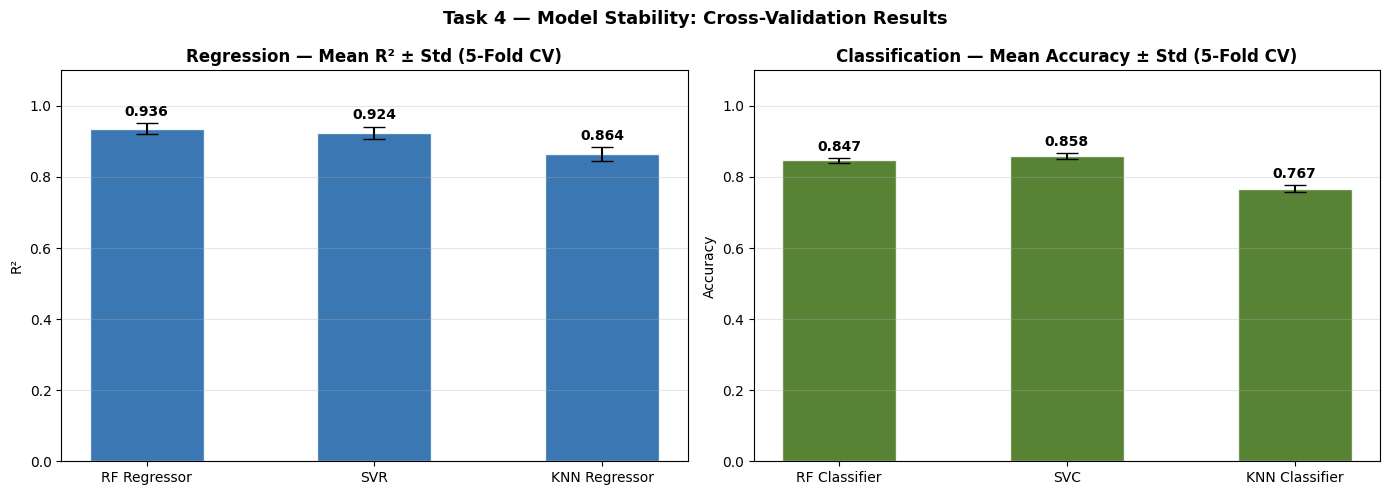

In [ ]:
#  Visualization: Mean ± Std for all models

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression
reg_names  = list(reg_cv_results.keys())
reg_means  = [reg_cv_results[n]['mean'] for n in reg_names]
reg_stds   = [reg_cv_results[n]['std']  for n in reg_names]

axes[0].bar(reg_names, reg_means, yerr=reg_stds,
            color='#185FA5', edgecolor='white',
            capsize=8, width=0.5, alpha=0.85)
axes[0].set_title('Regression — Mean R² ± Std (5-Fold CV)', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)
for i, (m, s) in enumerate(zip(reg_means, reg_stds)):
    axes[0].text(i, m + s + 0.02, f'{m:.3f}', ha='center', fontweight='bold')

# Classification
clf_names  = list(clf_cv_results.keys())
clf_means  = [clf_cv_results[n]['mean'] for n in clf_names]
clf_stds   = [clf_cv_results[n]['std']  for n in clf_names]

axes[1].bar(clf_names, clf_means, yerr=clf_stds,
            color='#3B6D11', edgecolor='white',
            capsize=8, width=0.5, alpha=0.85)
axes[1].set_title('Classification — Mean Accuracy ± Std (5-Fold CV)', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', alpha=0.3)
for i, (m, s) in enumerate(zip(clf_means, clf_stds)):
    axes[1].text(i, m + s + 0.02, f'{m:.3f}', ha='center', fontweight='bold')

plt.suptitle('Task 4 — Model Stability: Cross-Validation Results',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#Save cv_stability : will be used in results.json

cv_stability = {}

for name, res in reg_cv_results.items():
    cv_stability[name] = {
        'mean': res['mean'],
        'std':  res['std']
    }

for name, res in clf_cv_results.items():
    cv_stability[name] = {
        'mean': res['mean'],
        'std':  res['std']
    }


for model, vals in cv_stability.items():
    print(f"  {model}: mean={vals['mean']}, std={vals['std']}")


  RF Regressor: mean=0.9359, std=0.0164
  SVR: mean=0.9242, std=0.0175
  KNN Regressor: mean=0.8643, std=0.0192
  RF Classifier: mean=0.8471, std=0.0068
  SVC: mean=0.8579, std=0.0084
  KNN Classifier: mean=0.7675, std=0.0104


**Task 5** ENSAMPLING

In [ ]:
from sklearn.ensemble import VotingRegressor, VotingClassifier, StackingClassifier, StackingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# ENSEMBLE METHODS - Combining Models
print("\n" + "=" * 80)
print("STEP 3 — ENSEMBLE METHODS: Voting Classifier & Regressor")
print("=" * 80)
# 3.1 Voting Regressor (Average predictions from all 3 models)
voting_regressor = VotingRegressor(
    estimators=[
        ('RF', rf_reg_grid.best_estimator_),
        ('SVR', svr_grid.best_estimator_),
        ('KNN', knn_reg_grid.best_estimator_)
    ],
    weights=[5, 2, 1]
)

# Train the ensemble
voting_regressor.fit(X_train_proc, y_val_train)

# Predict
y_pred_ensemble_reg = voting_regressor.predict(X_test_proc)

# Evaluate
ensemble_r2 = r2_score(y_val_test, y_pred_ensemble_reg)
ensemble_rmse = np.sqrt(mean_squared_error(y_val_test, y_pred_ensemble_reg))
ensemble_mae = mean_absolute_error(y_val_test, y_pred_ensemble_reg)

print("\n Voting Regressor Performance:")
print(f"  R² Score: {ensemble_r2:.4f}")
print(f"  RMSE: {ensemble_rmse:.4f}")
print(f"  MAE: {ensemble_mae:.4f}")


STEP 3 — ENSEMBLE METHODS: Voting Classifier & Regressor

 Voting Regressor Performance:
  R² Score: 0.9152
  RMSE: 2.2929
  MAE: 0.2885


In [ ]:
# 3.2 Voting Classifier (Majority vote from all 3 models)
from sklearn.svm import SVC
import copy

svc_prob = SVC(
    **svc_grid.best_params_,
    probability=True,
    random_state=42
)
svc_prob.fit(X_train_clf_proc, y_tier_train)

voting_classifier = VotingClassifier(
    estimators=[
        ('RF', rf_clf_grid.best_estimator_),
        ('SVM', svc_prob),
        ('KNN', knn_clf_grid.best_estimator_)
    ],
    voting='soft',
    weights=[2, 3, 1] )

# Train the ensemble
voting_classifier.fit(X_train_clf_proc, y_tier_train)

# Predict
y_pred_ensemble_clf = voting_classifier.predict(X_test_clf_proc)

# Evaluate
ensemble_acc = accuracy_score(y_tier_test, y_pred_ensemble_clf)
ensemble_f1 = f1_score(y_tier_test, y_pred_ensemble_clf, average='weighted')

print("\n Voting Classifier Performance:")
print(f"  Accuracy: {ensemble_acc:.4f}")
print(f"  F1-Score (weighted): {ensemble_f1:.4f}")


 Voting Classifier Performance:
  Accuracy: 0.8681
  F1-Score (weighted): 0.8686


In [ ]:
# 3.3 Comparison: Individual Models vs Ensemble

print("\n" + "=" * 80)
print("COMPARISON: Individual Models vs Ensemble")
print("=" * 80)

# Regression Comparison
print("\n Regression - R² Scores:")
reg_comparison = []
for name, model in reg_models.items():
    r2 = model.score(X_test_proc, y_val_test)
    reg_comparison.append({'Model': name, 'R² Score': round(r2, 4)})

reg_comparison.append({'Model': ' Voting Ensemble', 'R² Score': round(ensemble_r2, 4)})
reg_comparison_df = pd.DataFrame(reg_comparison)
print(reg_comparison_df.to_string(index=False))

# Find best
best_reg = reg_comparison_df.loc[reg_comparison_df['R² Score'].idxmax()]
print(f"\n Best Regression Model: {best_reg['Model']} (R² = {best_reg['R² Score']})")

# Classification Comparison
print("\n Classification - Accuracy:")
clf_comparison = []
for name, model in clf_models.items():
    acc = model.score(X_test_clf_proc, y_tier_test)
    clf_comparison.append({'Model': name, 'Accuracy': round(acc, 4)})

clf_comparison.append({'Model': ' Voting Ensemble', 'Accuracy': round(ensemble_acc, 4)})
clf_comparison_df = pd.DataFrame(clf_comparison)
print(clf_comparison_df.to_string(index=False))

# Find best
best_clf = clf_comparison_df.loc[clf_comparison_df['Accuracy'].idxmax()]
print(f"\n Best Classification Model: {best_clf['Model']} (Accuracy = {best_clf['Accuracy']})")



COMPARISON: Individual Models vs Ensemble

 Regression - R² Scores:
           Model  R² Score
    RF Regressor    0.9183
             SVR    0.8923
   KNN Regressor    0.8343
 Voting Ensemble    0.9152

 Best Regression Model: RF Regressor (R² = 0.9183)

 Classification - Accuracy:
           Model  Accuracy
   RF Classifier    0.8500
             SVC    0.8645
  KNN Classifier    0.7794
 Voting Ensemble    0.8681

 Best Classification Model:  Voting Ensemble (Accuracy = 0.8681)


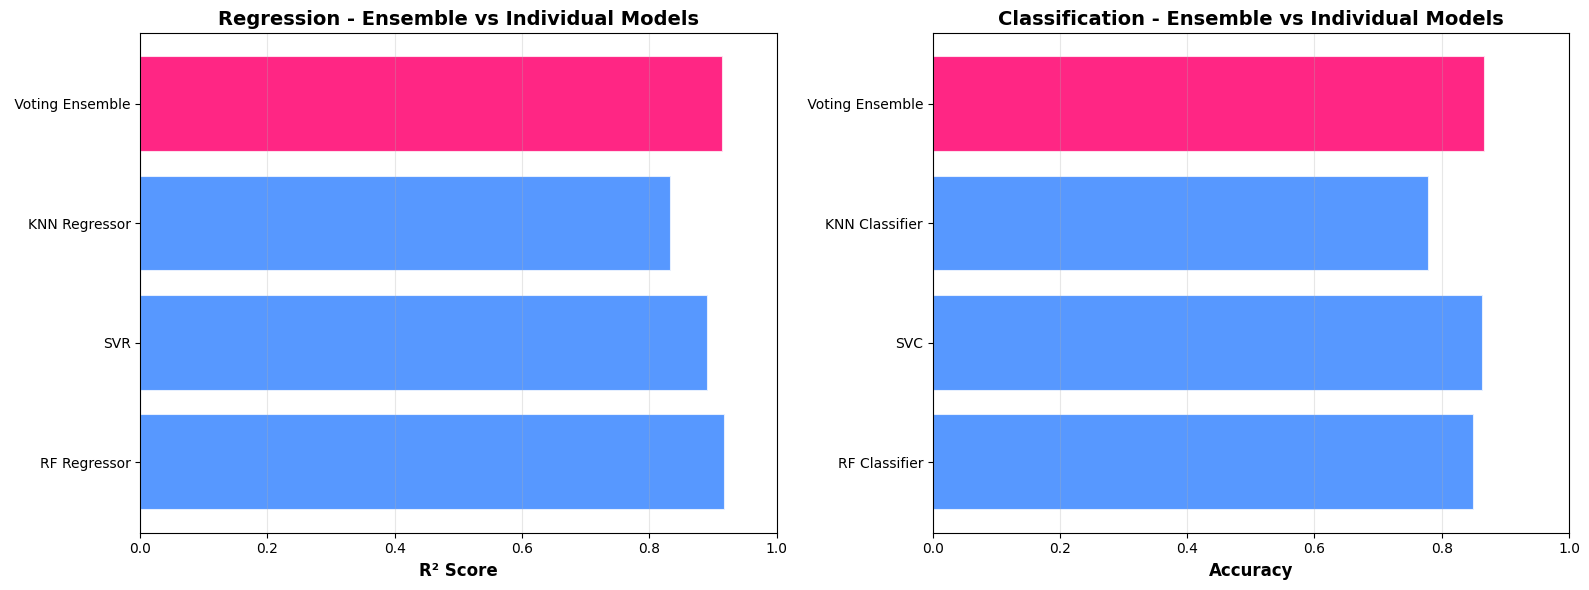


 Ensemble Analysis Complete!


In [ ]:
# Visualization - Ensemble vs Individual Models

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regression
models_reg = reg_comparison_df['Model'].values
scores_reg = reg_comparison_df['R² Score'].values
colors_reg = ['#3A86FF' if 'Ensemble' not in m else '#FF006E' for m in models_reg]

axes[0].barh(models_reg, scores_reg, color=colors_reg, alpha=0.85, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Regression - Ensemble vs Individual Models', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xlim([0, 1])

# Classification
models_clf = clf_comparison_df['Model'].values
scores_clf = clf_comparison_df['Accuracy'].values
colors_clf = ['#3A86FF' if 'Ensemble' not in m else '#FF006E' for m in models_clf]

axes[1].barh(models_clf, scores_clf, color=colors_clf, alpha=0.85, edgecolor='white', linewidth=1.5)
axes[1].set_xlabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Classification - Ensemble vs Individual Models', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim([0, 1])

plt.tight_layout()
plt.show()

print("\n Ensemble Analysis Complete!")


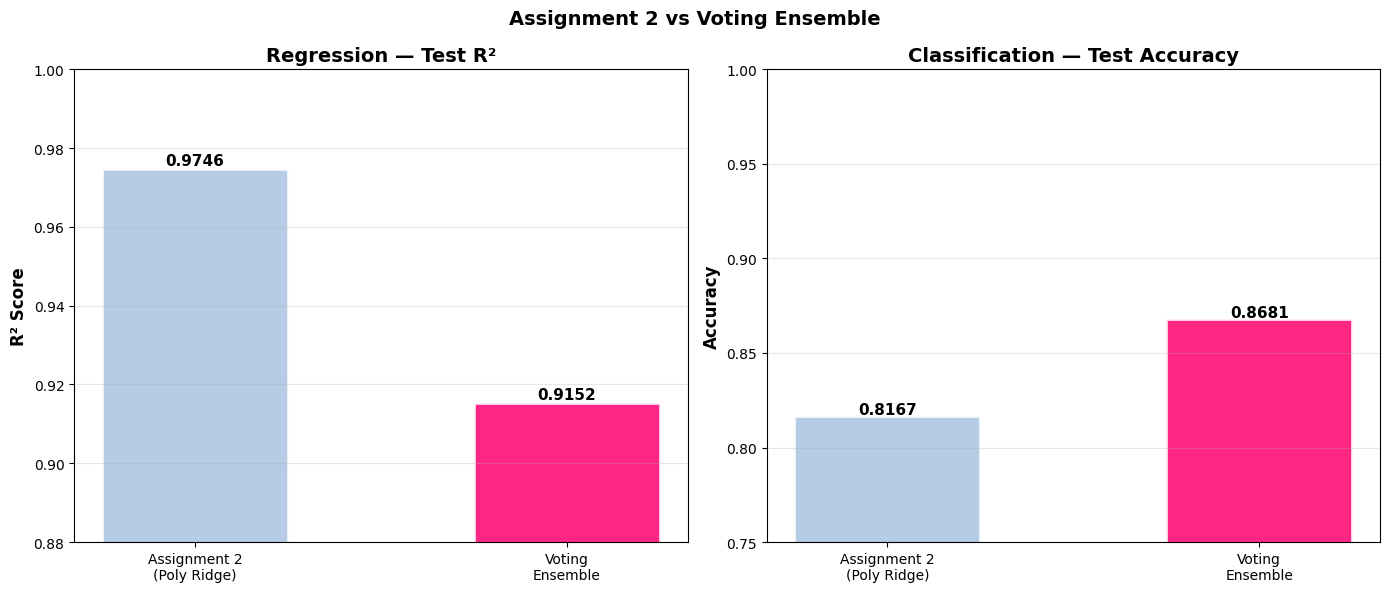

In [111]:
# Comparison: Assignment 2 vs Voting Ensemble
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Regression
categories = ['Assignment 2\n(Poly Ridge)', 'Voting\nEnsemble']
values_reg  = [0.9746, ensemble_r2]
colors_reg  = ['#A8C4E0', '#FF006E']

bars = axes[0].bar(categories, values_reg, color=colors_reg,
                   alpha=0.85, width=0.5, edgecolor='white', linewidth=2)
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Regression — Test R²', fontsize=14, fontweight='bold')
axes[0].set_ylim([0.88, 1.0])
axes[0].grid(axis='y', alpha=0.3)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.4f}', ha='center', fontweight='bold', fontsize=11)

# Classification
values_clf = [0.8167, ensemble_acc]
colors_clf = ['#A8C4E0', '#FF006E']

bars2 = axes[1].bar(categories, values_clf, color=colors_clf,
                    alpha=0.85, width=0.5, edgecolor='white', linewidth=2)
axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Classification — Test Accuracy', fontsize=14, fontweight='bold')
axes[1].set_ylim([0.75, 1.0])
axes[1].grid(axis='y', alpha=0.3)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.4f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Assignment 2 vs Voting Ensemble', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

 Voting was limited because KNN's weak performance pulled down the average.
 We upgraded to Stacking which uses a Meta-model to learn the best combination.


In [107]:
print("="*70)
print("STEP 2 — STACKING ENSEMBLE ")
print("="*70)

# Stacking Regressor
stacking_regressor = StackingRegressor(
    estimators=[
        ('RF',  rf_reg_grid.best_estimator_),
        ('SVR', svr_grid.best_estimator_),
        ('KNN', knn_reg_grid.best_estimator_)
    ],
    final_estimator=Ridge()
)
stacking_regressor.fit(X_train_proc, y_val_train)
y_pred_stack_reg  = stacking_regressor.predict(X_test_proc)
stacking_r2       = r2_score(y_val_test, y_pred_stack_reg)
stacking_rmse     = np.sqrt(mean_squared_error(y_val_test, y_pred_stack_reg))
stacking_mae      = mean_absolute_error(y_val_test, y_pred_stack_reg)

print(f"\n Stacking Regressor:")
print(f"  R²  : {stacking_r2:.4f}")
print(f"  RMSE: {stacking_rmse:.4f}")
print(f"  MAE : {stacking_mae:.4f}")

# Stacking Classifier
stacking_classifier = StackingClassifier(
    estimators=[
        ('RF',  rf_clf_grid.best_estimator_),
        ('SVM', svc_prob),
        ('KNN', knn_clf_grid.best_estimator_)
    ],
    final_estimator=LogisticRegression(max_iter=1000)
)
stacking_classifier.fit(X_train_clf_proc, y_tier_train)
y_pred_stack_clf = stacking_classifier.predict(X_test_clf_proc)
stacking_acc = accuracy_score(y_tier_test, y_pred_stack_clf)
stacking_f1 = f1_score(y_tier_test, y_pred_stack_clf, average='weighted')

print(f"\n Stacking Classifier:")
print(f"  Accuracy: {stacking_acc:.4f}")
print(f"  F1-Score: {stacking_f1:.4f}")


STEP 2 — STACKING ENSEMBLE 

 Stacking Regressor:
  R²  : 0.9187
  RMSE: 2.2451
  MAE : 0.3192

 Stacking Classifier:
  Accuracy: 0.8688
  F1-Score: 0.8690


In [109]:
#  Full Comparison Table
print("\n" + "="*70)
print("STEP 3 — FULL COMPARISON")
print("="*70)

rf_r2   = rf_reg_grid.best_estimator_.score(X_test_proc, y_val_test)
svr_r2  = svr_grid.best_estimator_.score(X_test_proc, y_val_test)
knn_r2  = knn_reg_grid.best_estimator_.score(X_test_proc, y_val_test)

rf_acc  = rf_clf_grid.best_estimator_.score(X_test_clf_proc, y_tier_test)
svc_acc = svc_grid.best_estimator_.score(X_test_clf_proc, y_tier_test)
knn_acc = knn_clf_grid.best_estimator_.score(X_test_clf_proc, y_tier_test)

reg_results = {
    'RF Regressor'    : rf_r2,
    'SVR'             : svr_r2,
    'KNN Regressor'   : knn_r2,
    'Voting Ensemble' : voting_regressor.score(X_test_proc, y_val_test),
    'Stacking Ensemble': stacking_r2,
}

clf_results = {
    'RF Classifier'    : rf_acc,
    'SVC'              : svc_acc,
    'KNN Classifier'   : knn_acc,
    'Voting Ensemble'  : voting_classifier.score(X_test_clf_proc, y_tier_test),
    'Stacking Ensemble': stacking_acc,
}

print("\nRegression R² Scores:")
for k, v in reg_results.items():
    print(f"  {k:25s}: {v:.4f}")

print("\nClassification Accuracy:")
for k, v in clf_results.items():
    print(f"  {k:25s}: {v:.4f}")



STEP 3 — FULL COMPARISON

Regression R² Scores:
  RF Regressor             : 0.9183
  SVR                      : 0.8923
  KNN Regressor            : 0.8343
  Voting Ensemble          : 0.9152
  Stacking Ensemble        : 0.9187

Classification Accuracy:
  RF Classifier            : 0.8500
  SVC                      : 0.8645
  KNN Classifier           : 0.7794
  Voting Ensemble          : 0.8681
  Stacking Ensemble        : 0.8688


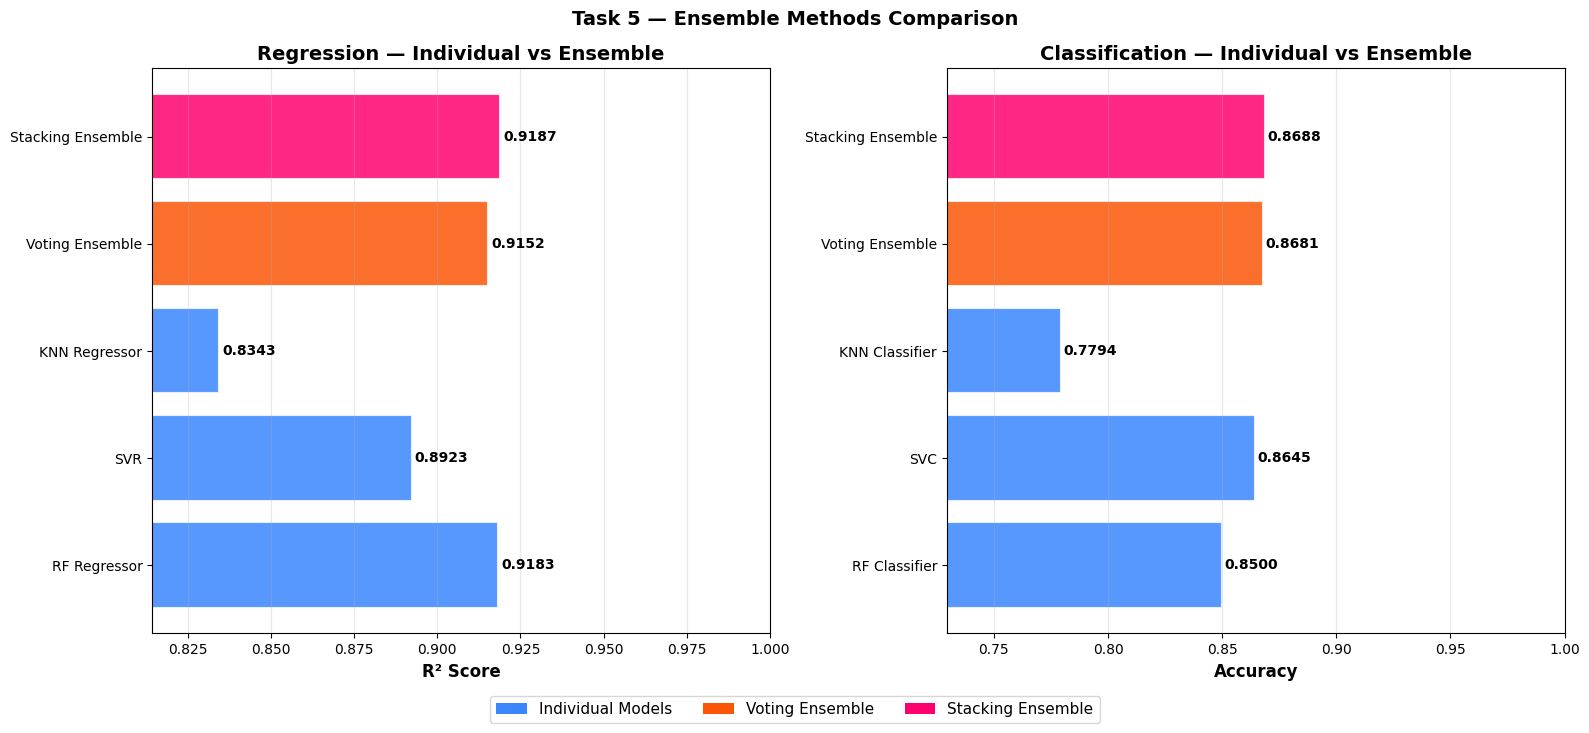

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

def get_colors(names):
    colors = []
    for n in names:
        if 'Stacking' in n:
            colors.append('#FF006E')
        elif 'Voting' in n:
            colors.append('#FB5607')
        else:
            colors.append('#3A86FF')
    return colors

# Regression
reg_names  = list(reg_results.keys())
reg_scores = list(reg_results.values())

bars = axes[0].barh(reg_names, reg_scores,
                    color=get_colors(reg_names),
                    alpha=0.85, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Regression — Individual vs Ensemble', fontsize=14, fontweight='bold')
axes[0].set_xlim([min(reg_scores) - 0.02, 1.0])
axes[0].grid(axis='x', alpha=0.3)
for bar, score in zip(bars, reg_scores):
    axes[0].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{score:.4f}', va='center', fontweight='bold', fontsize=10)

# Classification
clf_names  = list(clf_results.keys())
clf_scores = list(clf_results.values())

bars2 = axes[1].barh(clf_names, clf_scores,
                     color=get_colors(clf_names),
                     alpha=0.85, edgecolor='white', linewidth=1.5)
axes[1].set_xlabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Classification — Individual vs Ensemble', fontsize=14, fontweight='bold')
axes[1].set_xlim([min(clf_scores) - 0.05, 1.0])
axes[1].grid(axis='x', alpha=0.3)
for bar, score in zip(bars2, clf_scores):
    axes[1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{score:.4f}', va='center', fontweight='bold', fontsize=10)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3A86FF', label='Individual Models'),
    Patch(facecolor='#FB5607', label='Voting Ensemble'),
    Patch(facecolor='#FF006E', label='Stacking Ensemble'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=11, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Task 5 — Ensemble Methods Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


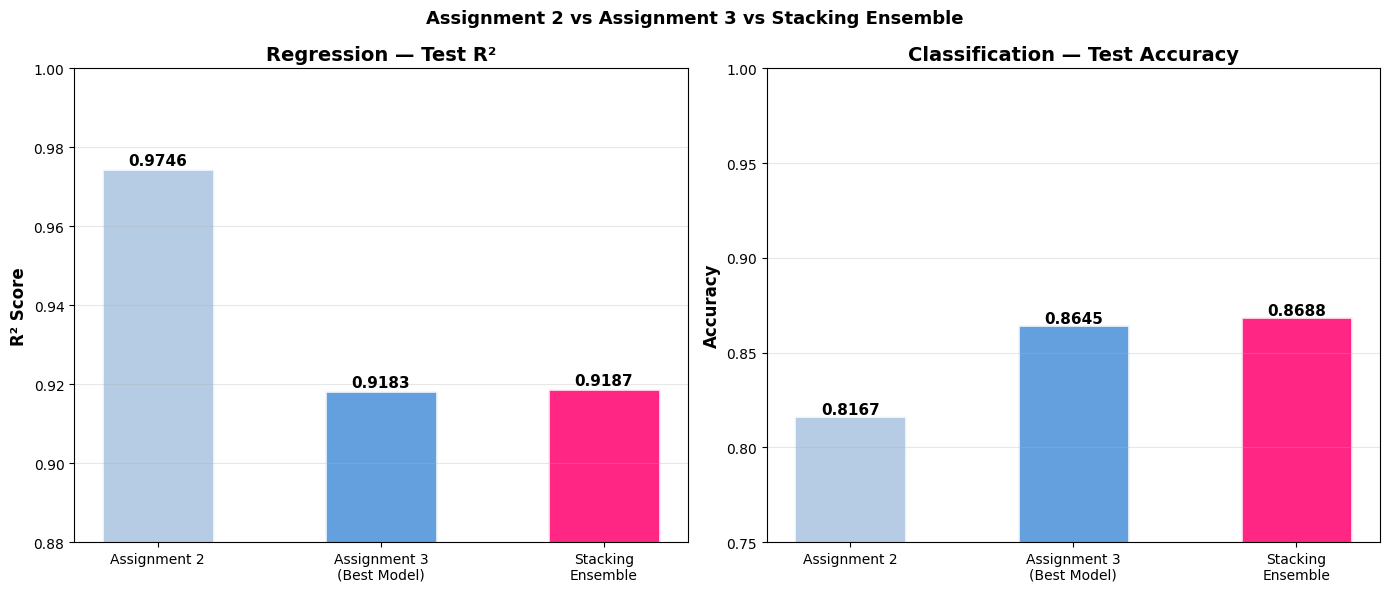

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

categories = ['Assignment 2', 'Assignment 3\n(Best Model)', 'Stacking\nEnsemble']

values_reg = [0.9746, 0.9183, stacking_r2]
values_clf = [0.8167, 0.8645, stacking_acc]

colors = ['#A8C4E0', '#4A90D9', '#FF006E']

# Regression
bars = axes[0].bar(categories, values_reg, color=colors,
                   alpha=0.85, width=0.5, edgecolor='white', linewidth=2)
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Regression — Test R²', fontsize=14, fontweight='bold')
axes[0].set_ylim([0.88, 1.0])
axes[0].grid(axis='y', alpha=0.3)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.4f}', ha='center', fontweight='bold', fontsize=11)

# Classification
bars2 = axes[1].bar(categories, values_clf, color=colors,
                    alpha=0.85, width=0.5, edgecolor='white', linewidth=2)
axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Classification — Test Accuracy', fontsize=14, fontweight='bold')
axes[1].set_ylim([0.75, 1.0])
axes[1].grid(axis='y', alpha=0.3)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.4f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Assignment 2 vs Assignment 3 vs Stacking Ensemble',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [116]:
from sklearn.pipeline import Pipeline

# Unified Pipeline — Regression
final_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessing_pipeline),
    ('ensemble',     stacking_regressor)
])

# Unified Pipeline — Classification
final_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessing_pipeline),
    ('ensemble',     stacking_classifier)
])

print("Unified Inference Pipeline Ready!")
print("Regression  Pipeline: Raw Player Data → Preprocessing → Stacking → Predicted Value")
print("Classification Pipeline: Raw Player Data → Preprocessing → Stacking → Performance Tier")

Unified Inference Pipeline Ready!
Regression  Pipeline: Raw Player Data → Preprocessing → Stacking → Predicted Value
Classification Pipeline: Raw Player Data → Preprocessing → Stacking → Performance Tier
